# Breakthrough analysis — nine measured runs (`newest runs/`)

Self-contained replacement for `src/solver/breakthrough_fit/` (12 modules) +
`src/solver/new_runs_pipeline.py`. Everything this notebook needs — parser,
24-model registry, multi-start fitter, statistics, performance metrics,
plotting — lives in the cells below.

**External inputs:** only the CSVs under `src/solver/data/newest runs/` and the
installed third-party packages (numpy, scipy, pandas, matplotlib; tabulate/tqdm
optional). No `import breakthrough_fit`, no `sys.path` surgery, no `%run`, no
helper `.py` next to the notebook. `src/solver/breakthrough_fit/` may be renamed
and this notebook still runs top-to-bottom.

**Data basis:** nine runs, 3×3 sweep of {5, 10, 15} % CO₂ × {0.05, 0.10, 0.15} lpm.
Column i.d. 8.2 mm, ~8 g PEI@SiO₂, bed 23.0–24.5 cm, ambient T, P ≈ 101 kPa.

---

### ⚑ Flag — stale repo documentation (not edited by this notebook)

`CLAUDE.md`, `AGENTS.md` and `src/docs/experimental-results.md` state that the
measured basis is **five** runs (`run 3/4/5/6/8`) at **8.5 mm** i.d. That is the
*previous* basis. This notebook uses the **nine-run / 8.2 mm** basis, per the
task specification and per each file's own embedded header block. The
discrepancy is flagged here and deliberately **not** reconciled in those docs.

### ⚑ Flag — two files excluded

`2026-07-17-conc15-flow0.1.csv` and `2026-07-17-conc15-flow0.15.csv` are raw
multi-channel sensor logs (format A): no mass, no bed height, no flow, no C₀
header. Their geometry is **not fabricated** — they are skipped, and the skip is
printed. Owner of the missing metadata: lab.

### ⚑ Flag — open inputs carried across verbatim

* Pellet density `ρ_p = 800 kg/m³` is an **assumption**, not a measurement.
* `eps_b = max(1 - rho_b/800, 0.3)` **floors** an unphysically low void fraction
  at 0.30.

Both are unresolved inputs owned by the lab. They look like bugs; they are not
ours to fix, and ε (and any ε-derived interstitial velocity) must not be treated
as physical until `ρ_p` is supplied.

## 0 — Environment

In [1]:
import sys
import warnings
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Callable, Iterable, Optional, Sequence

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats as _scistats
from scipy.optimize import OptimizeWarning, brentq, curve_fit, minimize
from scipy.special import erf

# NOTE (trap 1): breakthrough_fit/plots.py called `matplotlib.use("Agg")` at
# module import. That is deliberately NOT copied here — it would kill
# `%matplotlib inline` and nothing would display.
%matplotlib inline

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("scipy      ", scipy.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", matplotlib.__version__)
print("backend    ", matplotlib.get_backend())

try:
    from tabulate import tabulate as _tabulate
except ImportError:                                     # pragma: no cover
    def _tabulate(rows, headers, tablefmt="plain"):
        return pd.DataFrame(rows, columns=list(headers)).to_string(index=False)

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:                                     # pragma: no cover
    def _tqdm(it, **_kwargs):
        return it

python      3.14.4
numpy       2.4.4
scipy       1.17.1
pandas      3.0.3
matplotlib  3.10.8
backend     inline


### Paths and fixed constants

Trap 8: the original `new_runs_pipeline.py` mixed a repo-root-relative
`DATA_DIR` with a bare `OUT_DIR = Path("breakthrough_out")`, so outputs landed
wherever the process happened to be launched. Both are anchored to an absolute
`REPO` here, and output goes to `src/solver/breakthrough_out/<run_id>/`.

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until the repo's data directory is visible."""
    for cand in [start, *start.parents]:
        if (cand / "src" / "solver" / "data" / "newest runs").is_dir():
            return cand
    raise RuntimeError(f"repo root not found above {start}")


REPO = find_repo_root(Path.cwd().resolve())
DATA_DIR = REPO / "src" / "solver" / "data" / "newest runs"
OUT_DIR = REPO / "src" / "solver" / "breakthrough_out"

D_COL_M_FALLBACK = 0.0082        # 8.2 mm i.d. — fallback only; headers win
T_K_FALLBACK = 298.0             # K
P_PA_FALLBACK = 101_325.0        # Pa
RHO_P_ASSUMED = 800.0            # kg/m3 — ASSUMPTION, open input, owner: lab
EPS_B_FLOOR = 0.30               # floors an unphysically low void fraction
R_GAS = 8.314                    # J/mol/K

N_STARTS = 12                    # determinism: 12 starts ...
SEED = 42                        # ... seeded 42, re-seeded per model

# Cross-check table only. The geometry actually used comes from each file's own
# embedded header block; RUN_META exists so a header/metadata disagreement raises
# loudly instead of being silently preferred one way or the other.
RUN_META = {
    "2026-06-26-conc5-flow0.05":  dict(Q_lpm=0.05, m_g=8.0, L_bed_cm=23.5),
    "2026-07-03-conc5-flow0.10":  dict(Q_lpm=0.10, m_g=8.0, L_bed_cm=24.0),
    "2026-07-08-conc5-flow0.15":  dict(Q_lpm=0.15, m_g=8.0, L_bed_cm=23.5),
    "2026-07-08-conc10-flow0.05": dict(Q_lpm=0.05, m_g=8.0, L_bed_cm=23.0),
    "2026-07-08-conc10-flow0.10": dict(Q_lpm=0.10, m_g=8.0, L_bed_cm=23.3),
    "2026-07-08-conc10-flow0.15": dict(Q_lpm=0.15, m_g=8.0, L_bed_cm=24.0),
    "2026-07-10-conc15-flow0.05": dict(Q_lpm=0.05, m_g=8.0, L_bed_cm=24.5),
    "2026-07-10-conc15-flow0.10": dict(Q_lpm=0.10, m_g=8.0, L_bed_cm=24.0),
    "2026-07-15-conc15-flow0.15": dict(Q_lpm=0.15, m_g=8.0, L_bed_cm=24.0),
}
RUN_IDS = tuple(RUN_META)

print("REPO     ", REPO)
print("DATA_DIR ", DATA_DIR, "->", len(sorted(DATA_DIR.glob("*.csv"))), "csv files")
print("OUT_DIR  ", OUT_DIR)

REPO      C:\Users\User\Projects\GitHub\ProjID3
DATA_DIR  C:\Users\User\Projects\GitHub\ProjID3\src\solver\data\newest runs -> 11 csv files
OUT_DIR   C:\Users\User\Projects\GitHub\ProjID3\src\solver\breakthrough_out


## 1 — One file, raw

Before writing any parser, look at the bytes.

In [3]:
DEMO_ID = "2026-07-08-conc10-flow0.10"
demo_path = DATA_DIR / f"{DEMO_ID}.csv"

with open(demo_path, "r", encoding="utf-8", errors="replace") as fh:
    raw_head = [next(fh, "") for _ in range(13)]
print("".join(raw_head))
print(f"... total lines: {sum(1 for _ in open(demo_path, encoding='utf-8', errors='replace'))}")

"Mass: 8g
Bed height: 233 mm 
Flow rate: 100 ml/min
CO2: 10% (100580 ppm)
Tube diameter: 8.2 mm",,,,,,,,,,,,,,
,,,,,,,,,,,,,,
,,,,,,,,,,,,,,
,,,,,,,,,,,,,,
,,,,,,,,Mass,8,g,,tb,5.42,min
,,,,,,,,R,8.314,J/molK,,qb,0.28,mmol/g
,,,,,,,,P,101400,Pa,,te,72.85,min
,,,,,,,,v,0.1,dm3/min,,qe,1.13,mmol/g
,,,,,,,,C0,100580,ppm,,,,

... total lines: 1488


In [4]:
# Same thing through pandas, header=None, to see the real cell grid.
_probe = pd.read_csv(demo_path, header=None, engine="python", on_bad_lines="skip")
print("shape:", _probe.shape)
_probe.iloc[:12, [0, 1, 2, 3, 8, 9, 10, 12, 13, 14]]

shape: (1484, 15)


,0,1,2,3,8,9,10,12,13,14
0,Mass: 8g\nBed height: 233 mm \nFlow rate: 100 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,Mass,8,g,tb,5.42,min
5,NaN,NaN,NaN,NaN,R,8.314,J/molK,qb,0.28,mmol/g
6,NaN,NaN,NaN,NaN,P,101400,Pa,te,72.85,min
7,NaN,NaN,NaN,NaN,v,0.1,dm3/min,qe,1.13,mmol/g
8,NaN,NaN,NaN,NaN,C0,100580,ppm,NaN,NaN,NaN
9,Time,Time (min),CO2,C/C0,Mol adsorbed,Total (mol),mmol/g,NaN,NaN,NaN


### What the layout actually is (call it **Format D**)

* Row 0, col 0 — a *quoted five-line prose block* held in one CSV field:
  mass, bed height, flow rate, CO₂ %, tube diameter.
* Rows 4–8, cols 8–10 — a label/value/unit metadata table (`Mass`, `R`, `P`,
  `v`, `C0`).
* Rows 4–7, cols 12–14 — the **lab's own spreadsheet estimates** of
  `tb`/`qb`/`te`/`qe`. These are an independent cross-check, *never an input*.
* Then the real header row (`Time, Time (min), CO2, C/C0, ...`) and the data.

Two things must be handled deliberately:

1. **`Time (min)` is in minutes.** Every model and every downstream metric
   assumes seconds. A missed ×60 silently rescales every rate constant and every
   breakthrough time.
2. **The prose block duplicates the metadata table and `RUN_META`.** Parse it,
   then assert agreement and raise on mismatch.

## 2 — Parser, incrementally

Pull `t` [s] and `C/C₀` out of this one file with the least machinery that works.

header row index = 9;  n data rows = 1472
C0 (from file)   = 100580 ppm
t: 0.0 .. 8520.0 s  (142.0 min);  CO2: 0 .. 99290 ppm


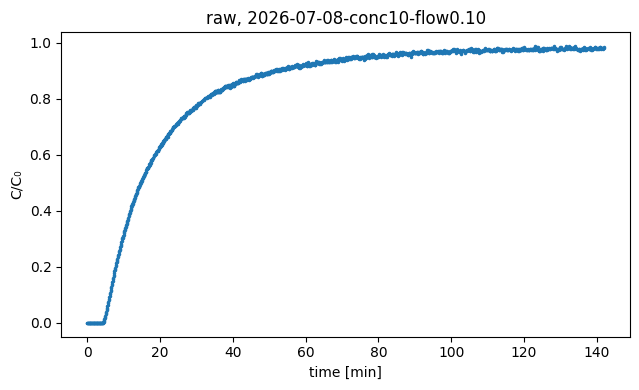

In [5]:
_hdr_idx = next(
    i for i in range(20)
    if str(_probe.iat[i, 0]).strip() == "Time" and str(_probe.iat[i, 1]).strip() == "Time (min)"
)
_data = _probe.iloc[_hdr_idx + 1:]
_t_scratch = pd.to_numeric(_data.iloc[:, 1], errors="coerce") * 60.0     # min -> s
_co2_scratch = pd.to_numeric(_data.iloc[:, 2], errors="coerce")          # ppm

# C0 read out of the file's own metadata block (col 8 = label, col 9 = value).
_labels = _probe.iloc[:_hdr_idx, 8].astype(str).str.strip().str.lower()
_c0_scratch = float(pd.to_numeric(_probe.iloc[:_hdr_idx, 9], errors="coerce")[_labels == "c0"].iloc[0])

print(f"header row index = {_hdr_idx};  n data rows = {_t_scratch.notna().sum()}")
print(f"C0 (from file)   = {_c0_scratch:.0f} ppm")
print(f"t: {_t_scratch.min():.1f} .. {_t_scratch.max():.1f} s  "
      f"({_t_scratch.max()/60:.1f} min);  CO2: {_co2_scratch.min():.0f} .. {_co2_scratch.max():.0f} ppm")

fig, ax = plt.subplots(figsize=(6.5, 4.0))
ax.plot(_t_scratch / 60.0, _co2_scratch / _c0_scratch, ".", ms=3)
ax.set_xlabel("time [min]"); ax.set_ylabel("C/C₀"); ax.set_title(f"raw, {DEMO_ID}")
fig.tight_layout()

That works. Promote it to functions.

### Definitions — parsing

Format D is the only reader the nine runs need, but A/B/C cost little and keep
the parser general (C reads the legacy `run 3/4/5/6/8` files, A the two excluded
`2026-07-17` sensor logs).

In [6]:
_DATETIME_FMT_A = "%m/%d/%y %H:%M:%S.%f"


@dataclass
class ParsedRun:
    """One breakthrough run: tidy `df` (t [s], C_C0) plus its own metadata."""

    df: pd.DataFrame
    c0_ppm: float
    flow_ml_min: Optional[float]
    temperature_K: Optional[float]
    pressure_Pa: Optional[float]
    filename: str
    run_id: str
    fmt: str                                   # "A", "B", "C" or "D"
    mass_g: Optional[float] = None
    bed_height_cm: Optional[float] = None
    tube_diameter_mm: Optional[float] = None
    lab_estimates: dict = field(default_factory=dict)   # lab's own tb/qb/te/qe


def despike(df: pd.DataFrame, threshold: float = 0.15) -> pd.DataFrame:
    """Interpolate point-wise sensor spikes in `C_C0` larger than `threshold`.

    A point is replaced by the mean of its neighbours only if the trace returns
    to the neighbourhood on the next sample — i.e. genuine steps survive.
    """
    y = df["C_C0"].to_numpy(dtype=float)
    if y.size < 3:
        return df
    d = np.abs(np.diff(y))
    bad = np.zeros_like(y, dtype=bool)
    bad[1:][d > threshold] = True
    for i in np.where(bad)[0]:
        if 0 < i < y.size - 1 and abs(y[i + 1] - y[i - 1]) < threshold:
            y[i] = 0.5 * (y[i - 1] + y[i + 1])
    out = df.copy()
    out["C_C0"] = y
    return out


def auto_detect(path: Path) -> str:
    """Classify a run CSV as format A, B, C or D from its first five lines."""
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        head = [next(fh, "") for _ in range(5)]
    blob = "".join(head).lower()
    if "bed height:" in blob or "tube diameter:" in blob:
        return "D"
    first = head[0].lower()
    if "c0" in first and "time" in first:
        return "B"
    if "sensor" in first or "co2" in head[1].lower():
        return "A"
    if head[1].count(",") >= 7:
        return "A"
    _data_row = head[1] if head[1].strip() else head[2]
    _parts = [p.strip().strip('"') for p in _data_row.split(",") if p.strip()]
    if len(_parts) <= 4 and _parts:
        try:
            datetime.strptime(_parts[0], _DATETIME_FMT_A)
            return "C"
        except ValueError:
            pass
    return "B"

In [7]:
import re


def parse_format_d(path: Path, c0_override: Optional[float] = None) -> ParsedRun:
    """Read a `newest runs/` CSV: prose header + I–O metadata block + data.

    `Time (min)` is converted to **seconds**; `C/C₀` is recomputed as
    `CO2 / C0` rather than trusting the spreadsheet's own column. Metadata is
    taken from the file itself — the prose block and the label/value table are
    cross-checked against each other and a mismatch prints a loud warning.
    """
    df_raw = pd.read_csv(path, header=None, engine="python", on_bad_lines="skip")

    hdr_idx = None
    for i in range(min(20, len(df_raw))):
        if (
            str(df_raw.iat[i, 0]).strip() == "Time"
            and df_raw.shape[1] > 1
            and str(df_raw.iat[i, 1]).strip() == "Time (min)"
        ):
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError(f"Format D: header row not found in {path}")

    # Label/value metadata table at cols 8-9 (Mass, R, P, v, C0).
    meta: dict[str, float] = {}
    if df_raw.shape[1] > 9:
        labels = df_raw.iloc[:hdr_idx, 8].astype(str).str.strip().str.lower()
        values = pd.to_numeric(df_raw.iloc[:hdr_idx, 9], errors="coerce")
        for label, value in zip(labels, values):
            if pd.notna(value):
                meta[label] = float(value)

    # Lab's own spreadsheet estimates at cols 12-13 (tb, qb, te, qe).
    lab: dict[str, float] = {}
    if df_raw.shape[1] > 13:
        labels = df_raw.iloc[:hdr_idx, 12].astype(str).str.strip().str.lower()
        values = pd.to_numeric(df_raw.iloc[:hdr_idx, 13], errors="coerce")
        for label, value in zip(labels, values):
            if pd.notna(value) and label in ("tb", "te", "qb", "qe"):
                lab[label] = float(value)

    # Prose block (row 0, col 0) — bed height & tube diameter live only here.
    prose = str(df_raw.iat[0, 0])
    bed_m = re.search(r"Bed height:\s*([\d.]+)\s*mm", prose, re.IGNORECASE)
    tube_m = re.search(r"Tube diameter:\s*([\d.]+)\s*mm", prose, re.IGNORECASE)
    mass_m = re.search(r"Mass:\s*([\d.]+)\s*g", prose, re.IGNORECASE)
    flow_m = re.search(r"Flow rate:\s*([\d.]+)\s*ml/min", prose, re.IGNORECASE)
    c0_m = re.search(r"CO2:.*?\(\s*([\d.]+)\s*ppm", prose, re.IGNORECASE)

    mass_g = meta.get("mass")
    if mass_m is not None:
        mass_prose = float(mass_m.group(1))
        if mass_g is not None and abs(mass_prose - mass_g) > 0.05:
            print(f"[WARN] {path.name}: prose mass {mass_prose:g} g vs table {mass_g:g} g")
        elif mass_g is None:
            mass_g = mass_prose

    c0_ppm = c0_override if c0_override is not None else meta.get("c0")
    if c0_m is not None and c0_ppm is not None and abs(float(c0_m.group(1)) - c0_ppm) > 1.0:
        print(f"[WARN] {path.name}: prose C0 {c0_m.group(1)} ppm vs table {c0_ppm:g} ppm")

    flow_ml_min = (meta["v"] * 1000.0) if "v" in meta else None      # dm3/min -> ml/min
    if flow_m is not None:
        flow_prose = float(flow_m.group(1))
        if flow_ml_min is not None and abs(flow_prose - flow_ml_min) > 0.5:
            print(f"[WARN] {path.name}: prose flow {flow_prose:g} vs table {flow_ml_min:g} ml/min")
        elif flow_ml_min is None:
            flow_ml_min = flow_prose

    # --- data block -------------------------------------------------------
    data = df_raw.iloc[hdr_idx + 1:]
    t_sec = pd.to_numeric(data.iloc[:, 1], errors="coerce") * 60.0   # MINUTES -> SECONDS
    co2 = pd.to_numeric(data.iloc[:, 2], errors="coerce")            # ppm

    out = pd.DataFrame({"t": t_sec, "C_C0": co2 / c0_ppm if c0_ppm else np.nan})
    out["CO2"] = co2
    out = out.dropna(subset=["t", "C_C0"]).copy()
    out = out.sort_values("t").drop_duplicates("t", keep="first")
    if c0_ppm is None and out["CO2"].notna().any():
        c0_ppm = float(out["CO2"].max())
        out["C_C0"] = out["CO2"] / c0_ppm
    out["C0_ppm"] = c0_ppm
    out["filename"] = path.name
    out["run_id"] = path.stem
    out = out[["t", "C_C0", "C0_ppm", "filename", "run_id"]].reset_index(drop=True)
    out = despike(out)

    temp = (
        pd.to_numeric(data.iloc[:, 5], errors="coerce").mean()
        if data.shape[1] > 5 else float("nan")
    )
    return ParsedRun(
        df=out,
        c0_ppm=c0_ppm,
        flow_ml_min=flow_ml_min,
        temperature_K=(temp + 273.15) if pd.notna(temp) else None,
        pressure_Pa=meta.get("p"),
        filename=path.name,
        run_id=path.stem,
        fmt="D",
        mass_g=mass_g,
        bed_height_cm=(float(bed_m.group(1)) / 10.0) if bed_m else None,
        tube_diameter_mm=float(tube_m.group(1)) if tube_m else None,
        lab_estimates=lab,
    )

In [8]:
def parse_format_a(path: Path, c0_override: Optional[float] = None) -> ParsedRun:
    """Raw multi-channel sensor log: row 2 declares channels, col 0 is a datetime.

    Carries no mass / bed height / flow, so `run_one` skips these files rather
    than fabricating geometry for them.
    """
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        _ = next(fh, "")
        header_row = next(fh, "").rstrip("\n").split(",")
    channel_names = [c.strip() for c in header_row]
    n_cols = len(channel_names)
    col_names = ["dt"] + [(c or f"col{i}") for i, c in enumerate(channel_names[1:], start=1)]
    if "CO2" not in col_names:
        col_names[1] = "CO2"

    df = pd.read_csv(path, header=None, skiprows=2, names=col_names,
                     usecols=range(n_cols), engine="python", on_bad_lines="skip")
    df["CO2"] = pd.to_numeric(df["CO2"], errors="coerce")
    df = df.dropna(subset=["CO2"]).copy()
    df["dt_parsed"] = pd.to_datetime(df["dt"].str.strip(), format=_DATETIME_FMT_A, errors="coerce")
    df = df.dropna(subset=["dt_parsed"]).copy()
    df = df.sort_values("dt_parsed").drop_duplicates("dt_parsed", keep="first")
    df["t"] = (df["dt_parsed"] - df["dt_parsed"].min()).dt.total_seconds()
    c0 = c0_override if c0_override else float(df["CO2"].max())
    df["C_C0"] = df["CO2"] / c0
    out = df[["t", "C_C0"]].reset_index(drop=True)
    out["C0_ppm"] = c0
    out["filename"] = path.name
    out["run_id"] = path.stem
    out = despike(out)
    temp = pd.to_numeric(df["Temperature"], errors="coerce").mean() if "Temperature" in df else np.nan
    pres = pd.to_numeric(df["Pressure"], errors="coerce").mean() if "Pressure" in df else np.nan
    return ParsedRun(
        df=out, c0_ppm=c0, flow_ml_min=None,
        temperature_K=(temp + 273.15) if pd.notna(temp) else None,
        pressure_Pa=float(pres) * 100.0 if pd.notna(pres) else None,
        filename=path.name, run_id=path.stem, fmt="A",
    )


def parse_format_c(path: Path, c0_override: Optional[float] = None) -> ParsedRun:
    """Legacy 2–4-column file (`run 3/4/5/6/8`): datetime + raw ppm.

    C0 = 92nd percentile; baseline = median of the first 10 points; t=0 is the
    first pair of consecutive points above 2 % of C0.
    """
    content = path.read_text(encoding="utf-8", errors="replace").splitlines()
    start = 1 if content and "ime" in content[0] else 0
    times, raw = [], []
    for line in content[start:]:
        parts = [p.strip().strip('"') for p in line.split(",")]
        parts = [p for p in parts if p]
        if len(parts) < 2:
            continue
        try:
            times.append(datetime.strptime(parts[0], _DATETIME_FMT_A))
            raw.append(float(parts[-1]))
        except (ValueError, IndexError):
            continue
    if not times:
        raise ValueError(f"No parseable rows in {path}")

    conc = np.array(raw, dtype=float)
    baseline = float(np.median(conc[:min(10, len(conc))]))
    c0 = c0_override if c0_override else float(np.percentile(conc, 92))
    thresh = baseline + 0.02 * (c0 - baseline)
    t0_idx = 0
    for i in range(len(conc) - 1):
        if conc[i] > thresh and conc[i + 1] > thresh:
            t0_idx = max(0, i - 1)
            break
    t_sec = np.array([(t - times[t0_idx]).total_seconds() for t in times], dtype=float)
    c_c0 = np.clip((conc - baseline) / max(c0 - baseline, 1.0), 0.0, 1.05)
    out = pd.DataFrame({"t": t_sec, "C_C0": c_c0})
    out["C0_ppm"] = c0
    out["filename"] = path.name
    out["run_id"] = path.stem
    return ParsedRun(df=despike(out.reset_index(drop=True)), c0_ppm=c0, flow_ml_min=None,
                     temperature_K=None, pressure_Pa=None, filename=path.name,
                     run_id=path.stem, fmt="C")


def parse_format_b(path: Path, c0_override: Optional[float] = None) -> ParsedRun:
    """Pre-processed spreadsheet: labelled `Time (s)` / `C/C0` + I–O metadata."""
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        row1 = next(fh).rstrip("\n").split(",")
    c0_ppm = c0_override
    if c0_ppm is None:
        try:
            c0_ppm = float(row1[4])
        except (IndexError, ValueError):
            c0_ppm = None

    df = pd.read_csv(path, header=None, skiprows=1, engine="python", on_bad_lines="skip")
    col_map: dict[str, int] = {}
    for i, label in enumerate(row1):
        lc = label.strip().lower()
        if lc == "time (s)":
            col_map["t"] = i
        elif lc == "c/c0":
            col_map["C_C0"] = i
        elif lc == "co2":
            col_map["CO2"] = i
    col_map.setdefault("t", 5)
    col_map.setdefault("C_C0", 8)

    out = pd.DataFrame({
        "t": pd.to_numeric(df.iloc[:, col_map["t"]], errors="coerce"),
        "C_C0": pd.to_numeric(df.iloc[:, col_map["C_C0"]], errors="coerce"),
    })
    out["CO2"] = (pd.to_numeric(df.iloc[:, col_map["CO2"]], errors="coerce")
                  if "CO2" in col_map else np.nan)
    out = out.dropna(subset=["t", "C_C0"]).copy()
    out = out.sort_values("t").drop_duplicates("t", keep="first")
    if c0_ppm is None and out["CO2"].notna().any():
        c0_ppm = float(out["CO2"].max())
    out["C0_ppm"] = c0_ppm
    out["filename"] = path.name
    out["run_id"] = path.stem
    out = despike(out[["t", "C_C0", "C0_ppm", "filename", "run_id"]].reset_index(drop=True))

    meta: dict[str, float] = {}
    if df.shape[1] >= 16:
        labels = df.iloc[:, 13].astype(str).str.strip().str.lower()
        values = pd.to_numeric(df.iloc[:, 14], errors="coerce")
        for label, value in zip(labels, values):
            if pd.notna(value) and label in ("p", "r", "v", "t"):
                meta[{"p": "P", "r": "R", "v": "v", "t": "T"}[label]] = float(value)
    return ParsedRun(df=out, c0_ppm=c0_ppm, flow_ml_min=meta.get("v"),
                     temperature_K=meta.get("T"), pressure_Pa=meta.get("P"),
                     filename=path.name, run_id=path.stem, fmt="B")


def parse_run(path: str | Path, c0_override: Optional[float] = None) -> ParsedRun:
    """Detect the format of a run CSV and dispatch to the right reader."""
    path = Path(path)
    fmt = auto_detect(path)
    return {"A": parse_format_a, "B": parse_format_b,
            "C": parse_format_c, "D": parse_format_d}[fmt](path, c0_override=c0_override)

### Validating the parser against the file's own header

Acceptance criterion 7: print parsed C₀, mass, bed height and tube diameter
beside the `RUN_META` values and assert they match.

In [9]:
def check_against_run_meta(run: ParsedRun, tol_L_cm: float = 0.05) -> None:
    """Assert a parsed run's own header agrees with the `RUN_META` cross-check table.

    Raises `AssertionError` on any disagreement — the header and `RUN_META` are
    two independent records of the same experiment, so a mismatch means one of
    them is wrong and must be resolved by hand, not silently preferred.
    """
    exp = RUN_META.get(run.run_id)
    if exp is None:
        raise AssertionError(f"{run.run_id}: not in RUN_META")
    got_Q = run.flow_ml_min / 1000.0
    assert abs(got_Q - exp["Q_lpm"]) < 1e-9, f"{run.run_id}: Q {got_Q} vs {exp['Q_lpm']}"
    assert abs(run.mass_g - exp["m_g"]) < 0.05, f"{run.run_id}: mass {run.mass_g} vs {exp['m_g']}"
    assert abs(run.bed_height_cm - exp["L_bed_cm"]) < tol_L_cm, \
        f"{run.run_id}: L_bed {run.bed_height_cm} vs {exp['L_bed_cm']}"
    assert abs(run.tube_diameter_mm - D_COL_M_FALLBACK * 1000.0) < 1e-9, \
        f"{run.run_id}: d_c {run.tube_diameter_mm} mm vs 8.2 mm"


demo_run = parse_run(demo_path)
check_against_run_meta(demo_run)
_e = RUN_META[DEMO_ID]
print(f"{'field':<16}{'parsed from file':>20}{'RUN_META':>14}")
print("-" * 50)
print(f"{'format':<16}{demo_run.fmt:>20}{'—':>14}")
print(f"{'C0 [ppm]':<16}{demo_run.c0_ppm:>20.0f}{'—':>14}")
print(f"{'mass [g]':<16}{demo_run.mass_g:>20.3f}{_e['m_g']:>14.3f}")
print(f"{'bed height [cm]':<16}{demo_run.bed_height_cm:>20.2f}{_e['L_bed_cm']:>14.2f}")
print(f"{'flow [lpm]':<16}{demo_run.flow_ml_min/1000:>20.3f}{_e['Q_lpm']:>14.3f}")
print(f"{'tube d [mm]':<16}{demo_run.tube_diameter_mm:>20.2f}{8.2:>14.2f}")
print(f"{'T [K]':<16}{demo_run.temperature_K:>20.2f}{'—':>14}")
print(f"{'P [Pa]':<16}{demo_run.pressure_Pa:>20.0f}{'—':>14}")
print(f"\nlab spreadsheet estimates (cross-check, NOT inputs): {demo_run.lab_estimates}")
print(f"n = {len(demo_run.df)} rows, t up to {demo_run.df['t'].max()/60:.1f} min")
demo_run.df.head()

field               parsed from file      RUN_META
--------------------------------------------------
format                             D             —
C0 [ppm]                      100580             —
mass [g]                       8.000         8.000
bed height [cm]                23.30         23.30
flow [lpm]                     0.100         0.100
tube d [mm]                     8.20          8.20
T [K]                         296.26             —
P [Pa]                        101400             —

lab spreadsheet estimates (cross-check, NOT inputs): {'tb': 5.42, 'qb': 0.28, 'te': 72.85, 'qe': 1.13}
n = 1472 rows, t up to 142.0 min


,t,C_C0,C0_ppm,filename,run_id
0,0.0,0.0,100580.0,2026-07-08-conc10-flow0.10.csv,2026-07-08-conc10-flow0.10
1,4.8,0.0,100580.0,2026-07-08-conc10-flow0.10.csv,2026-07-08-conc10-flow0.10
2,10.2,0.0,100580.0,2026-07-08-conc10-flow0.10.csv,2026-07-08-conc10-flow0.10
3,15.0,0.0,100580.0,2026-07-08-conc10-flow0.10.csv,2026-07-08-conc10-flow0.10
4,19.8,0.0,100580.0,2026-07-08-conc10-flow0.10.csv,2026-07-08-conc10-flow0.10


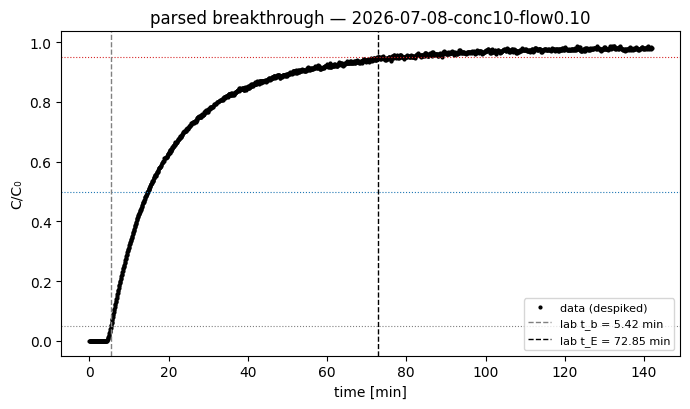

In [10]:
t_demo = demo_run.df["t"].to_numpy(dtype=float)
y_demo = demo_run.df["C_C0"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(t_demo / 60.0, y_demo, ".", ms=4, color="black", label="data (despiked)")
for lvl, c in ((0.05, "grey"), (0.5, "tab:blue"), (0.95, "tab:red")):
    ax.axhline(lvl, color=c, ls=":", lw=0.8)
ax.axvline(demo_run.lab_estimates["tb"], color="grey", ls="--", lw=1,
           label=f"lab t_b = {demo_run.lab_estimates['tb']:.2f} min")
ax.axvline(demo_run.lab_estimates["te"], color="black", ls="--", lw=1,
           label=f"lab t_E = {demo_run.lab_estimates['te']:.2f} min")
ax.set_xlabel("time [min]"); ax.set_ylabel("C/C₀")
ax.set_title(f"parsed breakthrough — {DEMO_ID}")
ax.legend(fontsize=8); fig.tight_layout()

The curve sits between the lab's own `t_b`/`t_E` marks, which is the unit
sanity check: had `Time (min)` been read as seconds, the whole trace would be
60× too wide and these vertical lines would land in the first pixel.

## 3 — One model

`model_M01` (Yoon–Nelson / Thomas / Bohart–Adams logistic) and one `curve_fit`.

### Definitions — numeric helpers and Group I

In [11]:
_EPS = 1e-300
_LOG_CLIP = 700.0        # exp overflow guard for float64


def _sigmoid(x: np.ndarray) -> np.ndarray:
    """Numerically stable logistic `1 / (1 + exp(x))`."""
    x = np.clip(x, -_LOG_CLIP, _LOG_CLIP)
    return np.where(x >= 0, np.exp(-x) / (1.0 + np.exp(-x)), 1.0 / (1.0 + np.exp(x)))


def _safe_pow(a, b: float):
    """Power with non-negative base, returning 0 where the base is negative."""
    a = np.asarray(a, dtype=float)
    out = np.zeros_like(a, dtype=float)
    pos = a > 0
    out[pos] = np.power(a[pos], b)
    return out


def model_M01(t: np.ndarray, k_YN: float, tau: float) -> np.ndarray:
    """Yoon–Nelson / Thomas / Bohart–Adams: `C/C0 = 1/(1 + exp[k_YN (tau - t)])`."""
    return _sigmoid(k_YN * (tau - t))

p0    : k_YN = 0.000988533 1/s   tau = 885 s
fitted: k_YN = 0.0017345 ± 2.5e-05 1/s
        tau  = 1088.28 ± 8.5 s  (18.14 min)


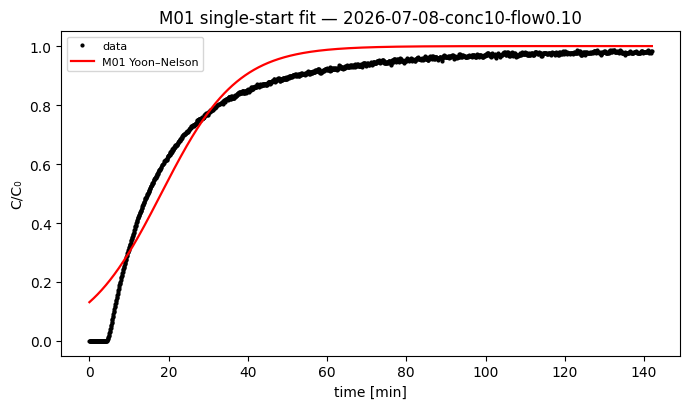

In [12]:
_p0 = (4.0 / max(t_demo[np.argmax(y_demo >= 0.95)] - t_demo[np.argmax(y_demo >= 0.05)], 1.0),
       float(t_demo[np.argmax(y_demo >= 0.5)]))
_popt, _pcov = curve_fit(model_M01, t_demo, y_demo, p0=_p0,
                         bounds=([1e-6, 1.0], [1.0, 1e6]), maxfev=5000)
_perr = np.sqrt(np.diag(_pcov))
print(f"p0    : k_YN = {_p0[0]:.6g} 1/s   tau = {_p0[1]:.6g} s")
print(f"fitted: k_YN = {_popt[0]:.6g} ± {_perr[0]:.2g} 1/s")
print(f"        tau  = {_popt[1]:.6g} ± {_perr[1]:.2g} s  ({_popt[1]/60:.2f} min)")

_y1 = model_M01(t_demo, *_popt)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(t_demo / 60.0, y_demo, ".", ms=4, color="black", label="data")
ax.plot(t_demo / 60.0, _y1, "r-", lw=1.6, label="M01 Yoon–Nelson")
ax.set_xlabel("time [min]"); ax.set_ylabel("C/C₀")
ax.set_title(f"M01 single-start fit — {DEMO_ID}")
ax.legend(fontsize=8); fig.tight_layout()

`tau` ≈ the observed 50 % crossing, which is what Yoon–Nelson's half-time means.

## 4 — Statistics

### Definitions — goodness of fit

In [13]:
@dataclass
class FitStats:
    """Goodness-of-fit statistics for one (model, dataset) pair."""

    n: int
    p: int
    rss: float
    tss: float
    r2: float
    adj_r2: float
    rmse: float
    chi2_red: float
    aic: float
    aicc: float
    aad: float
    aic_weight: float = float("nan")     # filled in by `rank_aicc`


def compute_stats(y_obs, y_pred, n_params: int, sigma=None) -> FitStats:
    """R², Adj R², RMSE, reduced χ², AIC, AICc and AAD for one fit.

    NaN predictions (implicit-model root-solve failures) are dropped before the
    comparison rather than propagating.
    """
    y_obs = np.asarray(y_obs, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_obs) & np.isfinite(y_pred)
    y_obs, y_pred = y_obs[mask], y_pred[mask]
    n = y_obs.size
    if n == 0:
        return FitStats(0, n_params, np.inf, np.inf, np.nan, np.nan, np.inf,
                        np.inf, np.inf, np.inf, np.inf)

    resid = y_obs - y_pred
    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((y_obs - float(np.mean(y_obs))) ** 2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    dof = max(n - n_params, 1)
    adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / dof if np.isfinite(r2) else np.nan
    rmse = float(np.sqrt(rss / max(n - 2, 1)))

    if sigma is not None:
        sigma = np.asarray(sigma, dtype=float)[mask]
        chi2 = float(np.sum((resid / np.maximum(sigma, 1e-12)) ** 2))
    else:
        chi2 = rss
    chi2_red = chi2 / dof

    aic = n * np.log(max(rss / n, 1e-300)) + 2.0 * n_params
    aicc = (aic + 2.0 * n_params * (n_params + 1) / (n - n_params - 1)
            if n - n_params - 1 > 0 else aic + np.inf)

    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.where(np.abs(y_obs) > 1e-6, np.abs(resid / y_obs), 0.0)
    return FitStats(n, n_params, rss, tss, r2, adj_r2, rmse, chi2_red,
                    aic, aicc, float(np.mean(rel)))


def f_test(rss1: float, rss2: float, df1: int, df2: int) -> float:
    """Nested-model F-test p-value; subscript 1 = simpler model (df1 > df2)."""
    delta_df = df1 - df2
    if delta_df <= 0 or rss2 <= 0 or df2 <= 0:
        return float("nan")
    f_stat = ((rss1 - rss2) / delta_df) / (rss2 / df2)
    if f_stat <= 0 or not np.isfinite(f_stat):
        return float("nan")
    return float(_scistats.f.sf(f_stat, delta_df, df2))


def rank_aicc(results: dict) -> dict:
    """Populate `aic_weight` **in place** from ΔAICc against the best model.

    PORTED VERBATIM (trap 4). This is a pairwise logit
    `1/(1 + exp(0.5·ΔAICc))`, *not* the conventional normalised Akaike weight
    `exp(-Δ/2)/Σexp(-Δ/2)`. "Correcting" it would change every `W_AICc` ever
    stored and break comparability with existing results.
    """
    aiccs = [(name, r.stats.aicc) for name, r in results.items()
             if np.isfinite(r.stats.aicc)]
    if not aiccs:
        return results
    aicc_min = min(a for _, a in aiccs)
    for name, r in results.items():
        if np.isfinite(r.stats.aicc):
            delta = float(r.stats.aicc - aicc_min)
            r.stats.aic_weight = 1.0 / (1.0 + np.exp(min(0.5 * delta, 700.0)))
    return results

In [14]:
_s = compute_stats(y_demo, _y1, n_params=2)
print(f"n        = {_s.n}")
print(f"p        = {_s.p}")
print(f"RSS      = {_s.rss:.6g}")
print(f"R2       = {_s.r2:.6f}")
print(f"Adj R2   = {_s.adj_r2:.6f}")
print(f"RMSE     = {_s.rmse:.6g}")
print(f"AIC      = {_s.aic:.4f}")
print(f"AICc     = {_s.aicc:.4f}")
print(f"AICc-AIC = {_s.aicc - _s.aic:.6f}   (= 2p(p+1)/(n-p-1) = "
      f"{2*_s.p*(_s.p+1)/(_s.n-_s.p-1):.6f})")
assert _s.aicc > _s.aic, "AICc must exceed AIC — the correction is strictly positive"
assert 0.0 <= _s.r2 <= 1.0, "R2 out of range"
print("\nchecks pass: AICc > AIC, R2 in [0, 1]")

n        = 1472
p        = 2
RSS      = 5.64738
R2       = 0.941973
Adj R2   = 0.941933
RMSE     = 0.0619819
AIC      = -8185.0084
AICc     = -8185.0002
AICc-AIC = 0.008169   (= 2p(p+1)/(n-p-1) = 0.008169)

checks pass: AICc > AIC, R2 in [0, 1]


## 5 — All 24 models

### Definitions — models M02–M24 (Groups II–XIII)

In [15]:
# --- Group II — Clark ------------------------------------------------------
def model_M02(t, r: float, A: float, n: float):
    """Clark model with generalised-Freundlich isotherm exponent `n`."""
    inner = 1.0 / (1.0 + A * np.exp(np.clip(-r * t, -_LOG_CLIP, _LOG_CLIP)))
    return _safe_pow(np.clip(inner, _EPS, 1.0), 1.0 / (n - 1.0))


def model_M03(t, r: float, A0: float, n: float, h: float):
    """Fractal-like Clark (Hu 2024); `h = 0` collapses to `model_M02`."""
    t = np.maximum(t, 1.0)
    expo = np.clip(-r / (1.0 - h) * np.power(t, 1.0 - h), -_LOG_CLIP, _LOG_CLIP)
    inner = 1.0 / (1.0 + A0 * np.exp(expo))
    return _safe_pow(np.clip(inner, _EPS, 1.0), 1.0 / (n - 1.0))


# --- Group III — Modified Dose–Response (Yan) ------------------------------
def model_M04(t, a: float, t50: float):
    """Modified dose–response parameterised on the half-time `t50`."""
    t = np.maximum(t, _EPS)
    return 1.0 - 1.0 / (1.0 + _safe_pow(t / t50, a))


# --- Group IV — Wolborska (early-region only) ------------------------------
def model_M05(t, slope: float, intercept: float):
    """Wolborska, linearised: `ln(C/C0) = slope·t + intercept`, returned as C/C0."""
    return np.exp(np.clip(slope * t + intercept, -_LOG_CLIP, 0.0))


# --- Group V — Gudermannian / erf / tanh / log-normal ----------------------
def model_M06(t, k: float, tau: float):
    """Gudermannian (Hu 2021)."""
    return 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(np.sinh(k * (t - tau))))


def model_M07(t, k: float, tau: float):
    """Error-function (Hu 2021)."""
    return 0.5 * (1.0 + erf(k * (t - tau)))


def model_M08(t, k: float, tau: float):
    """Hyperbolic-tangent (Hu 2019)."""
    return 0.5 * (1.0 + np.tanh(k * (t - tau)))


def model_M09(t, a: float, b: float):
    """Chu–Hashim log-normal breakthrough."""
    t = np.maximum(t, _EPS)
    return 0.5 * (1.0 + erf((np.log(t) - b) / (np.sqrt(2.0) * a)))


def model_M10(t, k0: float, tau0: float, h: float):
    """Fractal-like Gudermannian (Hu 2024)."""
    t = np.maximum(t, 1.0)
    return 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(np.sinh(k0 * np.power(t, -h) * (t - tau0))))


def model_M11(t, k0: float, tau0: float, h: float):
    """Fractal-like error-function (Hu 2024)."""
    t = np.maximum(t, 1.0)
    return 0.5 * (1.0 + erf(k0 * np.power(t, -h) * (t - tau0)))


# --- Group VI — Gompertz ---------------------------------------------------
def model_M12(t, alpha_G: float, beta_G: float):
    """Gompertz (Chu 2020)."""
    return np.exp(-np.exp(np.clip(alpha_G - beta_G * t, -_LOG_CLIP, _LOG_CLIP)))


def model_M13(t, alpha_G: float, beta_G: float):
    """Log-Gompertz (Chu 2020)."""
    t = np.maximum(t, _EPS)
    return np.exp(-np.exp(np.clip(alpha_G - beta_G * np.log(t), -_LOG_CLIP, _LOG_CLIP)))


# --- Group VII — Weibull & Avrami ------------------------------------------
def model_M14(t, tau: float, k: float):
    """Weibull (Chu 2021)."""
    t = np.maximum(t, 0.0)
    return 1.0 - np.exp(-np.clip(_safe_pow(t / tau, k), 0.0, _LOG_CLIP))


def weibull_derivative(t, tau: float, k: float):
    """`d(C/C0)/dt` of the Weibull curve — the wave-front rate used by P3."""
    t = np.maximum(t, _EPS)
    return (k / tau * _safe_pow(t / tau, k - 1.0)) * np.exp(-_safe_pow(t / tau, k))


def model_M15(t, k: float, n: float):
    """Avrami (Singh)."""
    t = np.maximum(t, 0.0)
    return 1.0 - np.exp(-np.clip(k * _safe_pow(t, n), 0.0, _LOG_CLIP))


# --- Group VIII — Klinkenberg / Dima ---------------------------------------
def model_M16(t, K_fa: float, K: float, eps_b: float = 0.37, u_over_x: float = 1.0):
    """Klinkenberg solution in canonical erf form (u/x absorbed into `K_fa`)."""
    zeta = K_fa / max(u_over_x, _EPS)
    t_corr = np.maximum(t - eps_b / max(u_over_x, _EPS), _EPS)
    tau_K = np.maximum(K_fa / max(K * (1.0 - eps_b), _EPS) * t_corr, _EPS)
    arg = (np.sqrt(tau_K) - np.sqrt(zeta)
           + 1.0 / (8.0 * np.sqrt(tau_K)) + 1.0 / (8.0 * np.sqrt(zeta)))
    return 0.5 * (1.0 + erf(arg))


def model_M17(t, v_d: float, sigma_a: float, x: float = 1.0):
    """Dima travelling-wave error-function."""
    return 0.5 * (1.0 + erf((v_d * t - x) / max(np.sqrt(2.0) * sigma_a, _EPS)))


# --- Group IX — Chern–Chien (implicit) -------------------------------------
def _chern_chien_langmuir_t_of_x(x, K_fa, K_L, q0, t12, eps=0.37, rho_b=700.0, C0=1.0):
    """Forward map `t(x)` for Chern–Chien Langmuir."""
    x = float(min(max(x, 1e-6), 1.0 - 1e-6))
    coeff = eps / max(K_fa * rho_b * q0 * C0, _EPS)
    term1 = np.log(2.0 * x / (1.0 - x))
    term2 = (1.0 / max(K_L * C0, _EPS)) * np.log(1.0 / (2.0 * (1.0 - x)))
    return t12 + coeff * (term1 + term2)


def model_M18(t, K_fa: float, K_L: float, q0: float, t12: float,
              eps: float = 0.37, rho_b: float = 700.0, C0: float = 1.0):
    """Chern–Chien Langmuir, inverted per point with `brentq`.

    Returns NaN where the root solve fails — expected behaviour, not a bug
    (trap 7); `compute_stats` drops those points.
    """
    out = np.empty_like(t, dtype=float)

    def residual(x, t_target):
        return _chern_chien_langmuir_t_of_x(x, K_fa, K_L, q0, t12, eps, rho_b, C0) - t_target

    for i, ti in enumerate(t):
        try:
            out[i] = brentq(residual, 1e-6, 1.0 - 1e-6, args=(float(ti),))
        except (ValueError, RuntimeError):
            out[i] = np.nan
    return out


def _chern_chien_freundlich_t_of_x(x, K_fa, n, q0, t12, eps=0.37, rho_b=700.0, C0=1.0):
    """Forward map `t(x)` for Chern–Chien Freundlich."""
    x = float(min(max(x, 1e-6), 1.0 - 1e-6))
    coeff = eps / max(K_fa * rho_b * q0 * C0, _EPS)
    term1 = np.log(2.0 * x / (1.0 - x))
    inner = (1.0 - x ** (n - 1.0)) / max(2.0 ** (1.0 - n), _EPS)
    term2 = -(1.0 / max(n - 1.0, _EPS)) * np.log(max(inner, _EPS))
    return t12 + coeff * (term1 + term2)


def model_M19(t, K_fa: float, n: float, q0: float, t12: float,
              eps: float = 0.37, rho_b: float = 700.0, C0: float = 1.0):
    """Chern–Chien Freundlich, inverted per point with `brentq` (NaN on failure)."""
    out = np.empty_like(t, dtype=float)

    def residual(x, t_target):
        return _chern_chien_freundlich_t_of_x(x, K_fa, n, q0, t12, eps, rho_b, C0) - t_target

    for i, ti in enumerate(t):
        try:
            out[i] = brentq(residual, 1e-6, 1.0 - 1e-6, args=(float(ti),))
        except (ValueError, RuntimeError):
            out[i] = np.nan
    return out


# --- Group X — log-modified logistic variants ------------------------------
def model_M20(t, k_BA: float, log_a0_over_C0: float):
    """Log-modified Bohart–Adams (Apiratikul & Chu).

    NOTE (trap 6): the registry advertises this parameter as `log_a0_C0` while
    the keyword here is `log_a0_over_C0`. Call positionally only.
    """
    t = np.maximum(t, _EPS)
    return _sigmoid(k_BA * (log_a0_over_C0 - np.log(t)))


def model_M21(t, k_YN: float, tau: float):
    """Log-modified Yoon–Nelson (Apiratikul & Chu)."""
    t = np.maximum(t, _EPS)
    return _sigmoid(k_YN * (np.log(max(tau, _EPS)) - np.log(t)))


# --- Group XI — n-order Bohart–Adams (Hu 2021) -----------------------------
def model_M22(t, k_n: float, a0: float, n: float, x_over_u: float = 1.0, C0: float = 1.0):
    """Generalised n-order Bohart–Adams; `n = 1` recovers the BA logistic."""
    n1 = n - 1.0
    if abs(n1) < 1e-3:
        return model_M01(t, k_n, x_over_u / max(k_n, _EPS))
    num = 1.0 + n1 * k_n * (a0 ** n1) * (C0 ** n1) * x_over_u
    den = 1.0 + n1 * k_n * (a0 ** n1) * (C0 ** n) * np.maximum(t, _EPS)
    ratio = np.where(den > 0, num / den, _EPS)
    bracket = (n * (a0 ** (1.0 - n)) * (C0 ** n1) * _safe_pow(ratio, 1.0 / n1)
               - n * (a0 ** (1.0 - n)) * (C0 ** n1))
    bracket = np.where(bracket > 0, bracket, _EPS)
    return np.clip(_safe_pow(bracket, -1.0 / n), 0.0, 1.0)


# --- Group XII — fractal-like Yoon–Nelson ----------------------------------
def model_M23(t, k_YN0: float, tau: float, h: float):
    """Fractal-like Yoon–Nelson (Hu 2024); recovers M01 when `h = 0`."""
    t = np.maximum(t, 1.0)
    tau = max(tau, 1.0)
    one_minus_h = max(1.0 - h, 1e-3)
    return _sigmoid((k_YN0 / one_minus_h) * (tau ** one_minus_h - np.power(t, one_minus_h)))


# --- Group XIII — parallel sigmoidal (Blagojev) ----------------------------
def model_M24(t, p: float, tau1: float, k1: float, tau2: float, k2: float):
    """Parallel two-component sigmoidal (Blagojev et al.)."""
    t = np.maximum(t, _EPS)
    p = float(np.clip(p, 0.0, 1.0))
    comp1 = 1.0 - 1.0 / (1.0 + _safe_pow(t / max(tau1, _EPS), k1))
    comp2 = 1.0 - 1.0 / (1.0 + _safe_pow(t / max(tau2, _EPS), k2))
    return p * comp1 + (1.0 - p) * comp2

### Definitions — initial-guess strategies and the registry

In [16]:
def _t50_estimate(t, y) -> float:
    """Interpolated time at which `C/C0` first crosses 0.5 (else `t.max()/2`)."""
    if y.size == 0:
        return 1.0
    mask = y >= 0.5
    if mask.any():
        idx = int(np.argmax(mask))
        if idx == 0:
            return float(max(t.min() + 1.0, 1.0))
        y0, y1 = float(y[idx - 1]), float(y[idx])
        t0, t1 = float(t[idx - 1]), float(t[idx])
        return t1 if y1 == y0 else float(t0 + (0.5 - y0) * (t1 - t0) / (y1 - y0))
    return float(max(t.max() / 2.0, 1.0))


def _t_at(t, y, level: float) -> float:
    """First sampled time at which `y` reaches `level` (else `t.max()`)."""
    mask = y >= level
    return float(t.max()) if not mask.any() else float(t[int(np.argmax(mask))])


def _init_M01(t, y):
    width = max(_t_at(t, y, 0.95) - _t_at(t, y, 0.05), 1.0)
    return (4.0 / width, _t50_estimate(t, y))


def _init_M02(t, y):
    return (4.0 / max(_t50_estimate(t, y), 1.0), 1.0, 2.0)


def _init_M03(t, y):
    return (4.0 / max(_t50_estimate(t, y), 1.0), 1.0, 2.0, 0.1)


def _init_M04(t, y):
    return (2.0, _t50_estimate(t, y))


def _init_M05(t, y):
    mask = (y > 0.005) & (y <= 0.15)
    if mask.sum() < 2:
        return (1e-3, -5.0)
    slope, intercept = np.polyfit(t[mask], np.log(y[mask]), 1)
    return (float(slope), float(intercept))


def _init_M06(t, y):
    return _init_M01(t, y)


def _init_M07(t, y):
    width = max(_t_at(t, y, 0.95) - _t_at(t, y, 0.05), 1.0)
    return (2.0 / width, _t50_estimate(t, y))


def _init_M08(t, y):
    return _init_M01(t, y)


def _init_M09(t, y):
    return (0.3, float(np.log(max(_t50_estimate(t, y), 1.0))))


def _init_M10(t, y):
    return (_init_M06(t, y)[0], _init_M06(t, y)[1], 0.1)


def _init_M11(t, y):
    return (_init_M07(t, y)[0], _init_M07(t, y)[1], 0.1)


def _init_M12(t, y):
    return (5.0, 5.0 / max(_t50_estimate(t, y), 1.0))


def _init_M13(t, y):
    return (5.0, 5.0 / max(np.log(max(_t50_estimate(t, y), 2.0)), 1.0))


def _init_M14(t, y):
    return (_t50_estimate(t, y) / (np.log(2.0) ** (1.0 / 1.5)), 1.5)


def _init_M15(t, y):
    n = 1.5
    return (np.log(2.0) / max(_t50_estimate(t, y) ** n, _EPS), n)


def _init_M16(t, y):
    return (4.0 / max(_t50_estimate(t, y), 1.0), 1.0)


def _init_M17(t, y):
    t50 = _t50_estimate(t, y)
    return (1.0 / max(t50, 1.0), max(t50 / 4.0, 1.0))


def _init_M18(t, y):
    t50 = _t50_estimate(t, y)
    return (4.0 / max(t50, 1.0), 1.0, 1.0, t50)


def _init_M19(t, y):
    t50 = _t50_estimate(t, y)
    return (4.0 / max(t50, 1.0), 2.0, 1.0, t50)


def _init_M20(t, y):
    return (4.0, float(np.log(max(_t50_estimate(t, y), 1.0))))


def _init_M21(t, y):
    return (4.0, _t50_estimate(t, y))


def _init_M22(t, y):
    return (1e-3, 1.0, 1.5)


def _init_M23(t, y):
    t50 = _t50_estimate(t, y)
    return (4.0 / max(t50, 1.0), t50, 0.1)


def _init_M24(t, y):
    t50 = _t50_estimate(t, y)
    return (0.5, max(t50 * 0.7, 1.0), 2.0, max(t50 * 1.3, 1.0), 2.0)


@dataclass
class BreakthroughModel:
    """Static descriptor for one breakthrough model."""

    code: str
    name: str
    func: Callable[..., np.ndarray]
    param_names: tuple[str, ...]
    bounds: tuple[tuple[float, float], ...]
    init_strategy: Callable[[np.ndarray, np.ndarray], tuple[float, ...]]
    group: str
    notes: str = ""
    early_only: bool = False        # restrict fit AND stats to 0.005 < C/C0 <= 0.15
    needs_implicit: bool = False    # L-BFGS-B on RSS instead of curve_fit
    extra_kwargs: dict = field(default_factory=dict)

    @property
    def p(self) -> int:
        return len(self.param_names)


REGISTRY: tuple[BreakthroughModel, ...] = (
    BreakthroughModel("M01", "Yoon-Nelson / Thomas / BA (logistic)", model_M01,
                      ("k_YN", "tau"), ((1e-6, 1.0), (1.0, 1e6)), _init_M01, "Logistic"),
    BreakthroughModel("M02", "Clark", model_M02,
                      ("r", "A", "n"), ((1e-6, 1.0), (1e-6, 1e6), (1.01, 10.0)),
                      _init_M02, "Clark"),
    BreakthroughModel("M03", "Fractal Clark", model_M03,
                      ("r", "A0", "n", "h"),
                      ((1e-6, 1.0), (1e-6, 1e6), (1.01, 10.0), (0.0, 0.99)),
                      _init_M03, "Clark"),
    BreakthroughModel("M04", "Modified Dose-Response (Yan)", model_M04,
                      ("a", "t50"), ((0.01, 20.0), (1.0, 1e6)), _init_M04, "Dose-Response"),
    BreakthroughModel("M05", "Wolborska (linearised, early)", model_M05,
                      ("slope", "intercept"), ((1e-6, 1.0), (-50.0, 0.0)),
                      _init_M05, "Wolborska", early_only=True),
    BreakthroughModel("M06", "Gudermannian (Hu 2021)", model_M06,
                      ("k", "tau"), ((1e-6, 1.0), (1.0, 1e6)), _init_M06, "ErfFamily"),
    BreakthroughModel("M07", "Error-Function (Hu 2021)", model_M07,
                      ("k", "tau"), ((1e-6, 1.0), (1.0, 1e6)), _init_M07, "ErfFamily"),
    BreakthroughModel("M08", "Tanh (Hu 2019)", model_M08,
                      ("k", "tau"), ((1e-6, 1.0), (1.0, 1e6)), _init_M08, "ErfFamily"),
    BreakthroughModel("M09", "Log-Normal (Chu-Hashim)", model_M09,
                      ("a", "b"), ((1e-3, 5.0), (-5.0, 20.0)), _init_M09, "ErfFamily"),
    BreakthroughModel("M10", "Fractal Gudermannian (Hu 2024)", model_M10,
                      ("k0", "tau0", "h"), ((1e-6, 1.0), (1.0, 1e6), (0.0, 0.99)),
                      _init_M10, "ErfFamily"),
    BreakthroughModel("M11", "Fractal Error-Function (Hu 2024)", model_M11,
                      ("k0", "tau0", "h"), ((1e-6, 1.0), (1.0, 1e6), (0.0, 0.99)),
                      _init_M11, "ErfFamily"),
    BreakthroughModel("M12", "Gompertz (Chu 2020)", model_M12,
                      ("alpha_G", "beta_G"), ((-20.0, 20.0), (1e-6, 1.0)),
                      _init_M12, "Gompertz"),
    BreakthroughModel("M13", "Log-Gompertz (Chu 2020)", model_M13,
                      ("alpha_G", "beta_G"), ((-50.0, 50.0), (1e-3, 50.0)),
                      _init_M13, "Gompertz"),
    BreakthroughModel("M14", "Weibull (Chu 2021)", model_M14,
                      ("tau", "k"), ((1.0, 1e6), (0.1, 10.0)), _init_M14, "Weibull"),
    BreakthroughModel("M15", "Avrami (Singh)", model_M15,
                      ("k", "n"), ((1e-12, 10.0), (0.1, 10.0)), _init_M15, "Weibull"),
    BreakthroughModel("M16", "Klinkenberg", model_M16,
                      ("K_fa", "K"), ((1e-6, 1.0), (1e-3, 1e4)), _init_M16, "Physics"),
    BreakthroughModel("M17", "Dima (wave erf)", model_M17,
                      ("v_d", "sigma_a"), ((1e-6, 1.0), (1e-3, 1e4)), _init_M17, "Physics"),
    BreakthroughModel("M18", "Chern-Chien Langmuir", model_M18,
                      ("K_fa", "K_L", "q0", "t12"),
                      ((1e-6, 1.0), (1e-6, 1e4), (1e-3, 50.0), (1.0, 1e6)),
                      _init_M18, "ChernChien", needs_implicit=True),
    BreakthroughModel("M19", "Chern-Chien Freundlich", model_M19,
                      ("K_fa", "n", "q0", "t12"),
                      ((1e-6, 1.0), (1.05, 10.0), (1e-3, 50.0), (1.0, 1e6)),
                      _init_M19, "ChernChien", needs_implicit=True),
    BreakthroughModel("M20", "Log-modified Bohart-Adams", model_M20,
                      ("k_BA", "log_a0_C0"), ((0.1, 50.0), (-5.0, 20.0)),
                      _init_M20, "LogLogistic"),
    BreakthroughModel("M21", "Log-modified Yoon-Nelson", model_M21,
                      ("k_YN", "tau"), ((0.1, 50.0), (1.0, 1e6)), _init_M21, "LogLogistic"),
    BreakthroughModel("M22", "n-Order Bohart-Adams", model_M22,
                      ("k_n", "a0", "n"), ((1e-8, 1.0), (1e-3, 1e4), (1.01, 5.0)),
                      _init_M22, "LogLogistic"),
    BreakthroughModel("M23", "Fractal Yoon-Nelson (Hu 2024)", model_M23,
                      ("k_YN0", "tau", "h"), ((1e-6, 50.0), (1.0, 1e6), (0.0, 0.95)),
                      _init_M23, "Fractal"),
    BreakthroughModel("M24", "Parallel two-component sigmoidal (Blagojev)", model_M24,
                      ("p", "tau1", "k1", "tau2", "k2"),
                      ((0.0, 1.0), (1.0, 1e6), (0.1, 20.0), (1.0, 1e6), (0.1, 20.0)),
                      _init_M24, "Parallel"),
)


def get_model(code: str) -> BreakthroughModel:
    """Look a model up by its `Mnn` code."""
    for m in REGISTRY:
        if m.code == code:
            return m
    raise KeyError(f"Unknown model code: {code}")


print(f"{len(REGISTRY)} models registered:")
print(pd.DataFrame([{"code": m.code, "name": m.name, "p": m.p, "group": m.group,
                     "early_only": m.early_only, "implicit": m.needs_implicit}
                    for m in REGISTRY]).to_string(index=False))

24 models registered:
code                                        name  p         group  early_only  implicit
 M01        Yoon-Nelson / Thomas / BA (logistic)  2      Logistic       False     False
 M02                                       Clark  3         Clark       False     False
 M03                               Fractal Clark  4         Clark       False     False
 M04                Modified Dose-Response (Yan)  2 Dose-Response       False     False
 M05               Wolborska (linearised, early)  2     Wolborska        True     False
 M06                      Gudermannian (Hu 2021)  2     ErfFamily       False     False
 M07                    Error-Function (Hu 2021)  2     ErfFamily       False     False
 M08                              Tanh (Hu 2019)  2     ErfFamily       False     False
 M09                     Log-Normal (Chu-Hashim)  2     ErfFamily       False     False
 M10              Fractal Gudermannian (Hu 2024)  3     ErfFamily       False     False
 M11      

### Definitions — the multi-start fitter

Determinism: `n_starts = 12`, `seed = 42`, and the RNG is **re-seeded per
model** so all 24 models see an identical start sequence. Start 1 is always the
data-driven initial guess; starts 2–12 are uniform inside the bounds box.

In [17]:
@dataclass
class FitResult:
    """Output of one model fit on one run."""

    code: str
    name: str
    params: np.ndarray
    param_names: tuple[str, ...]
    cov: Optional[np.ndarray]
    stderr: np.ndarray
    stats: FitStats
    converged: bool
    message: str
    y_pred: np.ndarray
    t: np.ndarray
    y_obs: np.ndarray
    extras: dict = field(default_factory=dict)


class ModelFitter:
    """Multi-start bounded least-squares fitter over the 24-model registry."""

    def __init__(self, n_starts: int = N_STARTS, seed: int = SEED,
                 registry: tuple[BreakthroughModel, ...] = REGISTRY,
                 extra_kwargs: Optional[dict[str, dict]] = None):
        self.n_starts = n_starts
        self.seed = seed
        self.registry = registry
        self.extra_kwargs = extra_kwargs or {}

    def fit_all(self, df: pd.DataFrame, progress=None) -> dict[str, FitResult]:
        """Fit every registry model to `df` (columns `t`, `C_C0`); rank by AICc."""
        t = df["t"].to_numpy(dtype=float)
        y = df["C_C0"].to_numpy(dtype=float)
        results: dict[str, FitResult] = {}
        iterator = self.registry if progress is None else progress(self.registry)
        for model in iterator:
            try:
                res = self.fit_one(model, t, y)
            except Exception as exc:                       # noqa: BLE001
                res = self._failed(model, t, y, str(exc))
            results[model.code] = res
        rank_aicc(results)
        return results

    def fit_one(self, model: BreakthroughModel, t: np.ndarray, y: np.ndarray) -> FitResult:
        """Fit one model from `n_starts` starting points, keeping the lowest RSS."""
        rng = np.random.default_rng(self.seed)      # re-seeded PER MODEL

        if model.early_only:
            # Trap 5: Wolborska is fitted on the early region only ...
            mask = (y > 0.005) & (y <= 0.15)
            if mask.sum() < 3:
                return self._failed(model, t, y, "insufficient early-region points")
            t_fit, y_fit = t[mask], y[mask]
        else:
            t_fit, y_fit = t, y

        kwargs = self.extra_kwargs.get(model.code, {})

        def f(t_in, *params):
            return model.func(t_in, *params, **kwargs)

        bounds_lo = np.array([b[0] for b in model.bounds])
        bounds_hi = np.array([b[1] for b in model.bounds])

        starts = [np.array(model.init_strategy(t_fit, y_fit), dtype=float)]
        for _ in range(self.n_starts - 1):
            starts.append(rng.uniform(bounds_lo, bounds_hi))

        best_params = best_cov = None
        best_rss = np.inf
        best_msg = "no successful fit"
        for s0 in starts:
            s0_clipped = np.clip(s0, bounds_lo, bounds_hi)
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", OptimizeWarning)
                    warnings.simplefilter("ignore", RuntimeWarning)
                    if model.needs_implicit:
                        params, cov, rss = self._minimize(
                            f, t_fit, y_fit, s0_clipped, bounds_lo, bounds_hi)
                    else:
                        params, cov = curve_fit(f, t_fit, y_fit, p0=s0_clipped,
                                                bounds=(bounds_lo, bounds_hi), maxfev=5000)
                        rss = float(np.sum((y_fit - f(t_fit, *params)) ** 2))
            except Exception as exc:                       # noqa: BLE001
                best_msg = str(exc)
                continue
            if np.isfinite(rss) and rss < best_rss:
                best_rss, best_params, best_cov = rss, params, cov
                best_msg = "converged"

        if best_params is None:
            return self._failed(model, t, y, best_msg)

        y_pred_full = f(t, *best_params)
        if model.early_only:
            # ... and trap 5 again: its STATISTICS are restricted to the same window.
            mask_eval = (y > 0.005) & (y <= 0.15)
            stats = (compute_stats(y[mask_eval], y_pred_full[mask_eval], model.p)
                     if mask_eval.sum() >= 3 else compute_stats(y, y_pred_full, model.p))
        else:
            stats = compute_stats(y, y_pred_full, model.p)

        stderr = (np.sqrt(np.clip(np.diag(best_cov), 0.0, None))
                  if best_cov is not None and np.all(np.isfinite(best_cov))
                  else np.full_like(best_params, np.nan, dtype=float))

        return FitResult(model.code, model.name, np.asarray(best_params, dtype=float),
                         model.param_names, best_cov, stderr, stats, True, best_msg,
                         y_pred_full, t, y,
                         extras={"early_only": model.early_only, "kwargs": kwargs})

    @staticmethod
    def _minimize(f, t, y, x0, lo, hi):
        """L-BFGS-B on RSS — used for the implicit models, where `curve_fit` chokes on NaN."""
        def rss_fn(theta):
            try:
                pred = f(t, *theta)
            except Exception:                              # noqa: BLE001
                return 1e12
            mask = np.isfinite(pred)
            if mask.sum() < 3:
                return 1e12
            return float(np.sum((y[mask] - pred[mask]) ** 2))

        res = minimize(rss_fn, x0, method="L-BFGS-B", bounds=list(zip(lo, hi)),
                       options={"maxiter": 200, "ftol": 1e-9})
        cov = None
        try:
            from scipy.optimize import approx_fprime
            eps = 1e-4 * np.maximum(np.abs(res.x), 1.0)
            n = len(res.x)
            H = np.zeros((n, n))
            grad0 = approx_fprime(res.x, rss_fn, eps)
            for i in range(n):
                xp = res.x.copy()
                xp[i] += eps[i]
                H[:, i] = (approx_fprime(xp, rss_fn, eps) - grad0) / eps[i]
            H = 0.5 * (H + H.T)
            cov = np.linalg.pinv(H) * (2.0 * res.fun / max(len(y) - n, 1))
        except Exception:                                  # noqa: BLE001
            cov = None
        return res.x, cov, float(res.fun)

    @staticmethod
    def _failed(model: BreakthroughModel, t, y, msg: str) -> FitResult:
        """A non-converged placeholder result with infinite information criteria."""
        stats = FitStats(int(np.size(y)), model.p, np.inf, np.inf, np.nan, np.nan,
                         np.inf, np.inf, np.inf, np.inf, np.inf)
        return FitResult(model.code, model.name, np.array([np.nan] * model.p),
                         model.param_names, None, np.array([np.nan] * model.p),
                         stats, False, msg, np.full_like(y, np.nan, dtype=float), t, y)


NESTED_PAIRS: tuple[tuple[str, str], ...] = (
    ("M01", "M02"),   # logistic vs Clark (adds n)
    ("M01", "M04"),   # logistic vs dose-response asymmetry
    ("M01", "M23"),   # logistic vs fractal YN (adds h)
    ("M02", "M03"),   # Clark vs fractal Clark (adds h)
    ("M07", "M11"),   # erf vs fractal erf (adds h)
    ("M06", "M10"),   # gudermannian vs fractal gudermannian (adds h)
)


def nested_ftests(results: dict[str, FitResult], n: int) -> pd.DataFrame:
    """F-test each nested (simple, complex) pair that converged."""
    rows = []
    for simple, complex_ in NESTED_PAIRS:
        if simple not in results or complex_ not in results:
            continue
        r1, r2 = results[simple], results[complex_]
        if not (r1.converged and r2.converged):
            continue
        df1, df2 = max(n - r1.stats.p, 1), max(n - r2.stats.p, 1)
        rows.append({"simple": simple, "complex": complex_,
                     "rss_simple": r1.stats.rss, "rss_complex": r2.stats.rss,
                     "df_simple": df1, "df_complex": df2,
                     "p_value": f_test(r1.stats.rss, r2.stats.rss, df1, df2)})
    return pd.DataFrame(rows)


def ranking_table(results: dict[str, FitResult]) -> pd.DataFrame:
    """Model ranking sorted by AICc (ascending = better)."""
    rows = [{"code": c, "name": r.name, "p": r.stats.p, "AdjR2": r.stats.adj_r2,
             "RMSE": r.stats.rmse, "AICc": r.stats.aicc, "W_AICc": r.stats.aic_weight,
             "chi2_nu": r.stats.chi2_red, "ok": r.converged}
            for c, r in results.items()]
    return pd.DataFrame(rows).sort_values("AICc", na_position="last").reset_index(drop=True)

### The expensive artefact — `RESULTS`, guarded by `REFIT`

24 models × 12 starts × 9 runs is the costly part. Fits accumulate into a
notebook-global `RESULTS[run_id][code] -> FitResult`. Only the fitting cell
writes it; every analysis cell downstream reads it. Set `REFIT = True` to force
a recompute.

In [18]:
REFIT = False
RESULTS: dict[str, dict[str, FitResult]] = globals().get("RESULTS", {})
PARSED: dict[str, ParsedRun] = globals().get("PARSED", {})
GEOM: dict[str, dict] = globals().get("GEOM", {})
PERF: dict[str, "PerformanceMetrics"] = globals().get("PERF", {})

FITTER = ModelFitter(n_starts=N_STARTS, seed=SEED)
print(f"REFIT={REFIT}; RESULTS currently holds {len(RESULTS)} run(s): {sorted(RESULTS)}")

REFIT=False; RESULTS currently holds 0 run(s): []


In [19]:
import time

if REFIT or DEMO_ID not in RESULTS:
    _t0 = time.time()
    RESULTS[DEMO_ID] = FITTER.fit_all(demo_run.df,
                                      progress=lambda it: _tqdm(it, desc=DEMO_ID, leave=False))
    PARSED[DEMO_ID] = demo_run
    print(f"fitted 24 models in {time.time() - _t0:.1f} s")
else:
    print(f"{DEMO_ID}: reusing cached fits (REFIT=False)")

_rank = ranking_table(RESULTS[DEMO_ID])
print(_tabulate(_rank.values.tolist(), headers=list(_rank.columns), tablefmt="plain"))

2026-07-08-conc10-flow0.10:   0%|          | 0/24 [00:00<?, ?it/s]

fitted 24 models in 30.1 s
code    name                                           p       AdjR2        RMSE        AICc          W_AICc      chi2_nu  ok
M11     Fractal Error-Function (Hu 2024)               3    0.999616  0.00503785  -15572        0.5           2.53972e-05  True
M03     Fractal Clark                                  4    0.999449  0.00603493  -15038.4      1.31303e-116  3.647e-05    True
M24     Parallel two-component sigmoidal (Blagojev)    5    0.99942   0.00618668  -14963.2      6.38299e-133  3.83533e-05  True
M13     Log-Gompertz (Chu 2020)                        2    0.998695  0.0092902   -13772.4      9.85968e-305  8.63078e-05  True
M10     Fractal Gudermannian (Hu 2024)                 3    0.998454  0.0101117   -13520.9      9.85968e-305  0.000102315  True
M04     Modified Dose-Response (Yan)                   2    0.996756  0.0146495   -12431.5      9.85968e-305  0.000214607  True
M20     Log-modified Bohart-Adams                      2    0.996756  0.0146495

In [20]:
# Re-running the cell above is now a no-op — this is the memoisation check.
_t0 = time.time()
if REFIT or DEMO_ID not in RESULTS:
    RESULTS[DEMO_ID] = FITTER.fit_all(demo_run.df)
print(f"second pass took {time.time() - _t0:.4f} s "
      f"(short-circuited: {DEMO_ID in RESULTS and not REFIT})")

second pass took 0.0003 s (short-circuited: True)


## 6 — Nested F-tests and performance metrics

In [21]:
_ft = nested_ftests(RESULTS[DEMO_ID], n=len(demo_run.df))
print(_tabulate(_ft.values.tolist(), headers=list(_ft.columns), tablefmt="plain"))

simple    complex      rss_simple    rss_complex    df_simple    df_complex         p_value
M01       M02             5.64738      3.40368           1470          1469    1.00763e-163
M01       M04             5.64738      0.315473          1470          1470  nan
M01       M23             5.64738      0.413453          1470          1469    0
M02       M03             3.40368      0.053538          1469          1468    0
M07       M11             6.21989      0.0373085         1470          1469    0
M06       M10             5.29184      0.150301          1470          1469    0


### Definitions — isotherm conversions and column performance

* `t_b` — time at C/C₀ = 0.05  ·  `t_E` — at 0.95  ·  `t50` — at 0.50
* `q_dyn = (ν C₀ / m) ∫₀^{t_E} (1 − C/C₀) dt`  [mol/kg]
* `L_MTZ = [1 − (t_E − t_b)/(2 t_E)] · L_bed`  [m]
* `ψ = t_b / t*`,  `t* = ∫₀^∞ (1 − C/C₀) dt`

In [22]:
def ppm_to_mol_m3(c_ppm: float, T_K: float = 298.0, P_Pa: float = 101_325.0) -> float:
    """Ideal-gas conversion ppm (vol) → mol/m³."""
    return c_ppm * 1e-6 * P_Pa / (R_GAS * T_K)


def back_calculate_q0(tau_YN: float, flow_vol_m3_s: float,
                      c0_mol_m3: float, mass_kg: float) -> float:
    """Equilibrium loading from the Yoon–Nelson half-time: `q0 = tau·ν·C0/m` [mol/kg]."""
    if mass_kg <= 0 or flow_vol_m3_s <= 0:
        return float("nan")
    return tau_YN * flow_vol_m3_s * c0_mol_m3 / mass_kg


def langmuir_linear_fit(c_in, q_e):
    """Linearised Langmuir `1/q_e = 1/q_m + 1/(q_m K_L C_in)` across runs."""
    c_in, q_e = np.asarray(c_in, float), np.asarray(q_e, float)
    mask = (c_in > 0) & (q_e > 0)
    if mask.sum() < 2:
        return dict(q_m=np.nan, K_L=np.nan, r2=np.nan)
    x, y = 1.0 / c_in[mask], 1.0 / q_e[mask]
    slope, intercept = np.polyfit(x, y, 1)
    resid = y - (slope * x + intercept)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(q_m=float(1.0 / intercept), K_L=float(intercept / slope),
                r2=float(1.0 - np.sum(resid ** 2) / ss_tot) if ss_tot > 0 else np.nan)


def freundlich_log_fit(c_e, q_e):
    """Linearised Freundlich `log q_e = log K_F + (1/n) log C_e` across runs."""
    c_e, q_e = np.asarray(c_e, float), np.asarray(q_e, float)
    mask = (c_e > 0) & (q_e > 0)
    if mask.sum() < 2:
        return dict(K_F=np.nan, inv_n=np.nan, r2=np.nan)
    x, y = np.log10(c_e[mask]), np.log10(q_e[mask])
    slope, intercept = np.polyfit(x, y, 1)
    resid = y - (slope * x + intercept)
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    return dict(K_F=float(10.0 ** intercept), inv_n=float(slope),
                r2=float(1.0 - np.sum(resid ** 2) / ss_tot) if ss_tot > 0 else np.nan)


@dataclass
class PerformanceMetrics:
    """Column-performance summary derived from one measured breakthrough curve."""

    t_b: float
    t_E: float
    t50: float
    q_dyn_mol_per_kg: float
    L_MTZ_m: float
    efficiency: float
    t_star: float


def _interp_time(t, y, level: float) -> float:
    """First time at which `y` crosses `level`, linearly interpolated."""
    if y.size == 0:
        return float("nan")
    above = np.where(y >= level)[0]
    if above.size == 0:
        return float("nan")
    i = int(above[0])
    if i == 0:
        return float(t[0])
    y0, y1 = float(y[i - 1]), float(y[i])
    t0, t1 = float(t[i - 1]), float(t[i])
    return t1 if y1 == y0 else float(t0 + (level - y0) * (t1 - t0) / (y1 - y0))


def t_breakthrough(t, y, level: float = 0.05) -> float:
    """Breakthrough time at an arbitrary `C/C0` level."""
    return _interp_time(t, y, level)


def q_dyn_trapz(t, y, flow_vol_m3_s: float, c0_mol_m3: float,
                mass_kg: float, t_E: Optional[float] = None) -> float:
    """Dynamic capacity `(ν C0/m) ∫ (1 − C/C0) dt` up to `t_E`, by trapezoid.

    Units: [m³/s]·[mol/m³]·[s]/[kg] = mol/kg. A spurious factor of 1000 in the
    denominator (which put q_dyn ~1000× low) was removed on 2026-05-31 and is
    NOT reinstated here — result CSVs written before that date are wrong.
    """
    if mass_kg <= 0 or flow_vol_m3_s <= 0:
        return float("nan")
    t, y = np.asarray(t, float), np.asarray(y, float)
    if t_E is not None and np.isfinite(t_E):
        mask = t <= t_E
        t_use, y_use = t[mask], y[mask]
    else:
        t_use, y_use = t, y
    if t_use.size < 2:
        return float("nan")
    return flow_vol_m3_s * c0_mol_m3 * float(np.trapezoid(1.0 - y_use, t_use)) / mass_kg


def l_mtz(t, y, L_bed_m: float) -> float:
    """Mass-transfer-zone length from the (t_b, t_E) pair."""
    tb, te = _interp_time(t, y, 0.05), _interp_time(t, y, 0.95)
    if not (np.isfinite(tb) and np.isfinite(te) and te > 0):
        return float("nan")
    return (1.0 - (te - tb) / (2.0 * te)) * L_bed_m


def column_efficiency(t, y) -> tuple[float, float]:
    """Return `(ψ, t*)` — stoichiometric efficiency and equilibrium time."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    if t.size < 2:
        return float("nan"), float("nan")
    t_star = float(np.trapezoid(1.0 - y, t))
    tb = _interp_time(t, y, 0.05)
    if t_star <= 0 or not np.isfinite(tb):
        return float("nan"), t_star
    return tb / t_star, t_star


def performance_metrics(t, y, flow_vol_m3_s: float, c0_mol_m3: float,
                        mass_kg: float, L_bed_m: float) -> PerformanceMetrics:
    """All six column-performance metrics for one run."""
    tb, te, t50 = (_interp_time(t, y, 0.05), _interp_time(t, y, 0.95),
                   _interp_time(t, y, 0.5))
    eff, t_star = column_efficiency(t, y)
    return PerformanceMetrics(
        t_b=tb, t_E=te, t50=t50,
        q_dyn_mol_per_kg=q_dyn_trapz(t, y, flow_vol_m3_s, c0_mol_m3, mass_kg, t_E=te),
        L_MTZ_m=l_mtz(t, y, L_bed_m), efficiency=eff, t_star=t_star,
    )

### Definitions — per-run geometry

Everything is derived from the run's own header. `ρ_p` and the `eps_b` floor
are carried across verbatim with their flags.

In [23]:
def run_geometry(run: ParsedRun) -> dict:
    """Column geometry and inlet conditions derived from one run's own header."""
    Q_lpm = run.flow_ml_min / 1000.0
    m_g = run.mass_g
    L_bed_cm = run.bed_height_cm
    d_col_m = (run.tube_diameter_mm * 1e-3) if run.tube_diameter_mm else D_COL_M_FALLBACK
    T_K = run.temperature_K or T_K_FALLBACK
    P_Pa = run.pressure_Pa or P_PA_FALLBACK

    A_c = np.pi * (d_col_m / 2.0) ** 2
    L_bed_m = L_bed_cm * 1e-2
    flow_m3_s = Q_lpm * 1e-3 / 60.0
    u = flow_m3_s / A_c
    rho_b = (m_g * 1e-3) / (A_c * L_bed_m)
    # ⚑ rho_p = 800 kg/m3 is ASSUMED, not measured, and the 0.30 floor hides an
    # ⚑ unphysically low void fraction. Open input, owner: lab. Do not "fix".
    eps_b = max(1.0 - rho_b / RHO_P_ASSUMED, EPS_B_FLOOR)
    v_int = u / max(eps_b, 1e-6)

    return dict(Q_lpm=Q_lpm, m_g=m_g, mass_kg=m_g * 1e-3, L_bed_cm=L_bed_cm,
                L_bed_m=L_bed_m, d_col_m=d_col_m, A_c=A_c, T_K=T_K, P_Pa=P_Pa,
                flow_m3_s=flow_m3_s, u=u, rho_b=rho_b, eps_b=eps_b, v_int=v_int,
                c0_ppm=run.c0_ppm,
                c0_mol_m3=ppm_to_mol_m3(run.c0_ppm, T_K=T_K, P_Pa=P_Pa))


GEOM[DEMO_ID] = run_geometry(demo_run)
_g = GEOM[DEMO_ID]
print(f"Q={_g['Q_lpm']:.3f} lpm | m={_g['m_g']:.4g} g | L_bed={_g['L_bed_cm']:.2f} cm | "
      f"d_c={_g['d_col_m']*1000:.1f} mm | T={_g['T_K']:.1f} K | P={_g['P_Pa']:.0f} Pa")
print(f"A_c={_g['A_c']*1e4:.4f} cm2  rho_b={_g['rho_b']:.1f} kg/m3  "
      f"eps={_g['eps_b']:.4f} (FLOORED — see flag)")
print(f"u={_g['u']*100:.4f} cm/s  v_int={_g['v_int']*100:.4f} cm/s  "
      f"C0={_g['c0_mol_m3']:.4f} mol/m3")

PERF[DEMO_ID] = performance_metrics(t_demo, y_demo, _g["flow_m3_s"], _g["c0_mol_m3"],
                                    _g["mass_kg"], _g["L_bed_m"])
_p = PERF[DEMO_ID]
print(f"\nt_b(5%)={_p.t_b/60:.2f} min   t_E(95%)={_p.t_E/60:.2f} min   t50={_p.t50/60:.2f} min")
print(f"q_dyn={_p.q_dyn_mol_per_kg:.4g} mol/kg   L_MTZ={_p.L_MTZ_m*100:.2f} cm   "
      f"psi={_p.efficiency:.3f}")
print(f"\nlab spreadsheet:  t_b={demo_run.lab_estimates['tb']:.2f} min   "
      f"t_E={demo_run.lab_estimates['te']:.2f} min   "
      f"q_e={demo_run.lab_estimates['qe']:.2f} mmol/g")

_r01 = RESULTS[DEMO_ID].get("M01")
if _r01 and _r01.converged:
    _k, _tau = _r01.params
    print(f"q0 from YN tau = "
          f"{back_calculate_q0(_tau, _g['flow_m3_s'], _g['c0_mol_m3'], _g['mass_kg']):.4g} mol/kg")

Q=0.100 lpm | m=8 g | L_bed=23.30 cm | d_c=8.2 mm | T=296.3 K | P=101400 Pa
A_c=0.5281 cm2  rho_b=650.2 kg/m3  eps=0.3000 (FLOORED — see flag)
u=3.1560 cm/s  v_int=10.5199 cm/s  C0=4.1407 mol/m3

t_b(5%)=5.43 min   t_E(95%)=72.93 min   t50=14.68 min
q_dyn=1.133 mol/kg   L_MTZ=12.52 cm   psi=0.226

lab spreadsheet:  t_b=5.42 min   t_E=72.85 min   q_e=1.13 mmol/g
q0 from YN tau = 0.9388 mol/kg


Computed `t_b`/`t_E` land within a few percent of the lab's own spreadsheet
values — an independent confirmation that the minutes→seconds conversion is
right. `q_dyn` is the same order as the lab's `q_e`, as expected.

## 7 — Plots P1–P7

### Definitions — travelling wave (P5) and the plot functions

`_save` both writes a 300-dpi PNG **and** returns the figure so it displays
inline (trap 3). `matplotlib.use("Agg")` is deliberately absent (trap 1).

In [24]:
def travelling_wave(x, t: float, L: float, v: float, k_ad_c_in: float, t_half: float):
    """Exact travelling-wave profile (Myers 2023, eq. 130)."""
    arg = np.clip(k_ad_c_in * ((x - L) / max(v, 1e-12) + (t_half - t)), -700.0, 700.0)
    return 1.0 / (1.0 + np.exp(arg))


def project_snapshots(L: float, v: float, k_ad_c_in: float, t_half: float,
                      t_snapshots: Sequence[float], n_nodes: int = 100):
    """Return `(x, C)` with `C` of shape `(len(t_snapshots), n_nodes)` over `x∈[0,L]`."""
    x = np.linspace(0.0, L, n_nodes)
    C = np.empty((len(t_snapshots), n_nodes), dtype=float)
    for i, t in enumerate(t_snapshots):
        C[i, :] = travelling_wave(x, float(t), L=L, v=v, k_ad_c_in=k_ad_c_in, t_half=t_half)
    return x, C


_DPI = 300
_FIGSIZE_M = (9.0, 5.5)
_FIGSIZE_L = (10.0, 7.0)


def _save(fig, out_dir: Optional[Path], stem: str):
    """Write `stem`.png at 300 dpi when `out_dir` is given, and return the figure."""
    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.tight_layout()
        fig.savefig(out_dir / f"{stem}.png", dpi=_DPI)
    return fig


def _vlines(ax, t, y) -> None:
    """Mark t_b (C/C0 = 0.05) and t_E (0.95) on a time axis in minutes."""
    tb, te = t_breakthrough(t, y, 0.05), t_breakthrough(t, y, 0.95)
    if np.isfinite(tb):
        ax.axvline(tb / 60.0, color="grey", ls=":", lw=1, label="t_b (C/C₀=0.05)")
    if np.isfinite(te):
        ax.axvline(te / 60.0, color="black", ls=":", lw=1, label="t_E (C/C₀=0.95)")


def _rolling_mean(x, window: int = 11):
    """Centred moving average; all-NaN when the series is shorter than `window`."""
    if x.size < window:
        return np.full_like(x, np.nan, dtype=float)
    return np.convolve(x, np.ones(window) / window, mode="same")

In [25]:
def plot_P1(run_id: str, results: dict[str, FitResult],
            out_dir: Optional[Path] = None, top_n: int = 8):
    """P1 — predicted vs observed parity for the `top_n` fits by R²."""
    fig, ax = plt.subplots(figsize=_FIGSIZE_M)
    ranked = sorted((r for r in results.values() if r.converged),
                    key=lambda r: -r.stats.r2 if np.isfinite(r.stats.r2) else 1.0)[:top_n]
    cmap = plt.get_cmap("tab10")
    for i, r in enumerate(ranked):
        mask = np.isfinite(r.y_pred)
        ax.scatter(r.y_obs[mask], r.y_pred[mask], s=10, alpha=0.55, color=cmap(i % 10),
                   label=f"{r.code}  R²={r.stats.r2:0.4f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim(-0.02, 1.05); ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("Observed C/C₀"); ax.set_ylabel("Predicted C/C₀")
    ax.set_title(f"P1 — predicted vs observed ({run_id})")
    ax.legend(fontsize=7, loc="lower right")
    return _save(fig, out_dir, f"P1_{run_id}")


def plot_P2(run_id: str, df, results: dict[str, FitResult], out_dir: Optional[Path] = None):
    """P2 — breakthrough curves grouped by the isotherm each model assumes."""
    fig, axes = plt.subplots(1, 2, figsize=_FIGSIZE_L, sharey=True)
    t = df["t"].to_numpy(dtype=float)
    y = df["C_C0"].to_numpy(dtype=float)
    t_min = t / 60.0
    for ax, codes, title in ((axes[0], ("M01", "M02", "M16", "M17"), "Langmuir-isotherm fits"),
                             (axes[1], ("M04", "M19"), "Freundlich-isotherm fits")):
        ax.scatter(t_min, y, s=10, color="black", alpha=0.6, label="data")
        for code in codes:
            r = results.get(code)
            if r is None or not r.converged:
                continue
            mask = np.isfinite(r.y_pred)
            param_str = ", ".join(f"{n}={v:0.3g}" for n, v in zip(r.param_names, r.params))
            ax.plot(t_min[mask], r.y_pred[mask], lw=1.5,
                    label=f"{r.code}  R²={r.stats.r2:0.3f}\n  {param_str}")
        _vlines(ax, t, y)
        ax.set_xlabel("time [min]"); ax.set_title(title); ax.set_ylim(-0.02, 1.05)
        ax.legend(fontsize=7, loc="lower right")
    axes[0].set_ylabel("C/C₀")
    fig.suptitle(f"P2 — breakthrough curves ({run_id})")
    return _save(fig, out_dir, f"P2_{run_id}")


def plot_P3(run_id: str, df, results: dict[str, FitResult], out_dir: Optional[Path] = None):
    """P3 — Weibull (M14) fit and its derivative, the wave-front rate."""
    fig, axes = plt.subplots(1, 2, figsize=_FIGSIZE_L)
    t = df["t"].to_numpy(dtype=float)
    y = df["C_C0"].to_numpy(dtype=float)
    t_min = t / 60.0
    r = results.get("M14")
    axes[0].scatter(t_min, y, s=10, color="black", alpha=0.6, label="data")
    if r is not None and r.converged:
        axes[0].plot(t_min, r.y_pred, "r-", lw=1.5, label="Weibull (M14)")
        tau, k = r.params
        axes[1].plot(t_min, weibull_derivative(t, tau, k) * 60.0, "r-", lw=1.5)
        if k > 1.0:
            t_peak = tau * (1.0 - 1.0 / k) ** (1.0 / k)
            axes[1].axvline(t_peak / 60.0, color="grey", ls="--",
                            label=f"t_peak = {t_peak/60.0:0.1f} min")
    axes[0].set_xlabel("time [min]"); axes[0].set_ylabel("C/C₀")
    axes[0].set_title("Weibull fit"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("time [min]"); axes[1].set_ylabel("d(C/C₀)/dt  [min⁻¹]")
    axes[1].set_title("Wave-front rate (Weibull derivative)"); axes[1].legend(fontsize=8)
    fig.suptitle(f"P3 — Weibull ({run_id})")
    return _save(fig, out_dir, f"P3_{run_id}")


def plot_P4(run_id: str, df, results: dict[str, FitResult], out_dir: Optional[Path] = None):
    """P4 — Thomas/YN vs dose–response, with the asymmetry band and residuals."""
    fig, axes = plt.subplots(2, 1, figsize=_FIGSIZE_L, sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})
    t = df["t"].to_numpy(dtype=float)
    y = df["C_C0"].to_numpy(dtype=float)
    t_min = t / 60.0
    axes[0].scatter(t_min, y, s=10, color="black", alpha=0.6, label="data")
    r01, r04 = results.get("M01"), results.get("M04")
    y1 = r01.y_pred if (r01 and r01.converged) else None
    y4 = r04.y_pred if (r04 and r04.converged) else None
    if y1 is not None:
        axes[0].plot(t_min, y1, "b-", lw=1.5, label=f"M01 Thomas/YN  R²={r01.stats.r2:0.3f}")
    if y4 is not None:
        axes[0].plot(t_min, y4, "g-", lw=1.5, label=f"M04 Dose-Response  R²={r04.stats.r2:0.3f}")
    if y1 is not None and y4 is not None:
        axes[0].fill_between(t_min, np.minimum(y1, y4), np.maximum(y1, y4),
                             color="grey", alpha=0.2, label="asymmetry band")
    axes[0].set_ylabel("C/C₀"); axes[0].legend(fontsize=8)
    if y1 is not None:
        axes[1].plot(t_min, y - y1, "b-", lw=0.8, label="M01 residual")
    if y4 is not None:
        axes[1].plot(t_min, y - y4, "g-", lw=0.8, label="M04 residual")
    axes[1].axhline(0.0, color="black", lw=0.6)
    axes[1].set_xlabel("time [min]"); axes[1].set_ylabel("residual"); axes[1].legend(fontsize=8)
    fig.suptitle(f"P4 — Thomas vs Dose-Response ({run_id})")
    return _save(fig, out_dir, f"P4_{run_id}")


def plot_P5(run_id: str, results: dict[str, FitResult], L_bed_m: float,
            v_interstitial: float, out_dir: Optional[Path] = None):
    """P5 — MTZ propagation snapshots from the M01 travelling wave, u and L swept."""
    r = results.get("M01")
    if r is None or not r.converged:
        fig, ax = plt.subplots(figsize=_FIGSIZE_M)
        ax.text(0.5, 0.5, "M01 fit unavailable — P5 skipped", ha="center", va="center")
        ax.set_axis_off()
        return _save(fig, out_dir, f"P5_{run_id}")

    k_YN, tau = r.params                      # tau acts as the t_half proxy
    t_E_idx = np.searchsorted(r.y_pred, 0.95)
    t_E = float(r.t[min(t_E_idx, r.t.size - 1)]) if t_E_idx > 0 else float(r.t[-1])
    snap_times = np.array([0.2, 0.4, 0.6, 0.8, 1.0]) * t_E

    fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.5), sharey=True)
    sweeps = [
        ("Baseline L", [(L_bed_m, v_interstitial, k_YN)]),
        ("Vary u (±50%)", [(L_bed_m, 0.5 * v_interstitial, k_YN),
                           (L_bed_m, v_interstitial, k_YN),
                           (L_bed_m, 1.5 * v_interstitial, k_YN)]),
        ("Vary L (×0.5, ×1, ×2)", [(0.5 * L_bed_m, v_interstitial, k_YN),
                                   (L_bed_m, v_interstitial, k_YN),
                                   (2.0 * L_bed_m, v_interstitial, k_YN)]),
    ]
    cmap = plt.get_cmap("viridis")
    for ax, (title, cases) in zip(axes, sweeps):
        for j, (L_use, v_use, k_use) in enumerate(cases):
            x, C = project_snapshots(L=L_use, v=v_use, k_ad_c_in=k_use, t_half=tau,
                                     t_snapshots=snap_times, n_nodes=100)
            for i, t_snap in enumerate(snap_times):
                ax.plot(x / max(L_use, 1e-9), C[i],
                        color=cmap(i / max(len(snap_times) - 1, 1)),
                        alpha=0.4 + 0.2 * j, lw=1.0 + 0.3 * j,
                        label=(f"t={t_snap/60.0:0.1f} min" if j == len(cases) - 1 else None))
        ax.set_xlabel("x / L"); ax.set_title(title); ax.set_ylim(-0.02, 1.05)
        if title.startswith("Baseline"):
            ax.set_ylabel("C/C₀")
        ax.legend(fontsize=7, loc="lower right")
    fig.suptitle(f"P5 — MTZ propagation ({run_id})")
    return _save(fig, out_dir, f"P5_{run_id}")


def plot_P6(run_id: str, df, results: dict[str, FitResult],
            f_p_ba_vs_fractal: Optional[float], out_dir: Optional[Path] = None):
    """P6 — standard YN (M01) vs fractal YN (M23), with `h` and the F-test p-value."""
    fig, axes = plt.subplots(2, 2, figsize=_FIGSIZE_L, sharex=True,
                             gridspec_kw={"height_ratios": [3, 1]})
    t = df["t"].to_numpy(dtype=float)
    y = df["C_C0"].to_numpy(dtype=float)
    t_min = t / 60.0
    for col, (code, title) in enumerate((("M01", "Standard YN"), ("M23", "Fractal YN"))):
        ax_top, ax_bot = axes[0, col], axes[1, col]
        r = results.get(code)
        ax_top.scatter(t_min, y, s=10, color="black", alpha=0.5, label="data")
        if r is not None and r.converged:
            ax_top.plot(t_min, r.y_pred, "r-", lw=1.5, label=f"{code}  R²={r.stats.r2:0.3f}")
            ax_bot.bar(t_min, y - r.y_pred,
                       width=(t_min[-1] - t_min[0]) / max(t.size, 1), color="grey")
            if code == "M23" and "h" in r.param_names:
                h_val = r.params[r.param_names.index("h")]
                p_str = (f"  F-test p={f_p_ba_vs_fractal:0.3g}"
                         if f_p_ba_vs_fractal is not None and np.isfinite(f_p_ba_vs_fractal)
                         else "")
                ax_top.text(0.02, 0.95, f"h = {h_val:0.3f}{p_str}", transform=ax_top.transAxes,
                            fontsize=9, va="top", bbox=dict(facecolor="white", alpha=0.6))
        ax_top.set_title(title); ax_top.set_ylim(-0.02, 1.05); ax_top.legend(fontsize=8)
        ax_bot.axhline(0, color="black", lw=0.6); ax_bot.set_xlabel("time [min]")
        if col == 0:
            ax_top.set_ylabel("C/C₀"); ax_bot.set_ylabel("residual")
    fig.suptitle(f"P6 — Standard YN vs Fractal YN ({run_id})")
    return _save(fig, out_dir, f"P6_{run_id}")


def plot_P7(run_id: str, df, results: dict[str, FitResult],
            out_dir: Optional[Path] = None, codes: Optional[Iterable[str]] = None):
    """P7 — residual-vs-time panel for every converged model."""
    t = df["t"].to_numpy(dtype=float)
    y = df["C_C0"].to_numpy(dtype=float)
    t_min = t / 60.0
    converged = [r for r in results.values() if r.converged]
    if codes is not None:
        converged = [r for r in converged if r.code in codes]
    if not converged:
        fig, ax = plt.subplots(figsize=_FIGSIZE_M)
        ax.text(0.5, 0.5, "no converged fits", ha="center", va="center")
        ax.set_axis_off()
        return _save(fig, out_dir, f"P7_{run_id}")
    cols = 4
    rows = int(np.ceil(len(converged) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.0 * cols, 2.8 * rows), sharex=True)
    axes = np.atleast_2d(axes).ravel()
    for ax, r in zip(axes, converged):
        resid = y - r.y_pred
        ax.scatter(t_min, resid, s=6, alpha=0.5, color="steelblue")
        ax.plot(t_min, _rolling_mean(resid, 11), color="orange", lw=1.0)
        ax.axhline(0.0, color="black", lw=0.6)
        ax.set_title(f"{r.code}  χ²_red={r.stats.chi2_red:0.3g}", fontsize=9)
        ax.tick_params(labelsize=7)
    for ax in axes[len(converged):]:
        ax.set_axis_off()
    fig.suptitle(f"P7 — residual diagnostics ({run_id})")
    fig.supxlabel("time [min]"); fig.supylabel("y_obs − y_pred")
    return _save(fig, out_dir, f"P7_{run_id}")

### P1–P7 for the demo run — displayed inline *and* written to disk

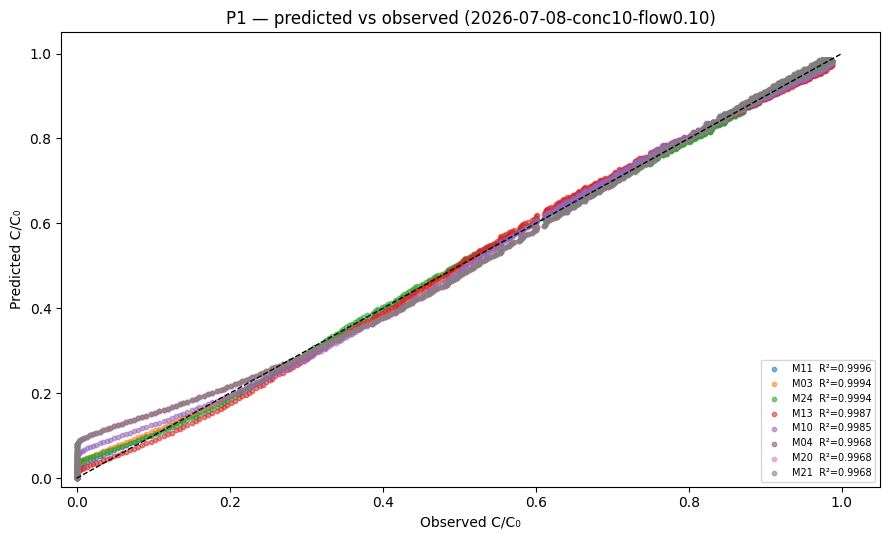

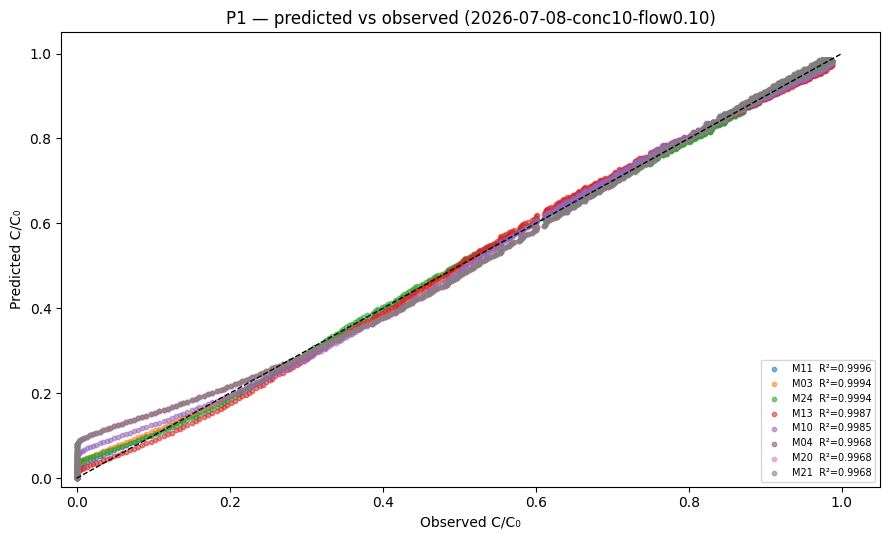

In [26]:
_demo_out = OUT_DIR / DEMO_ID
plot_P1(DEMO_ID, RESULTS[DEMO_ID], out_dir=_demo_out)

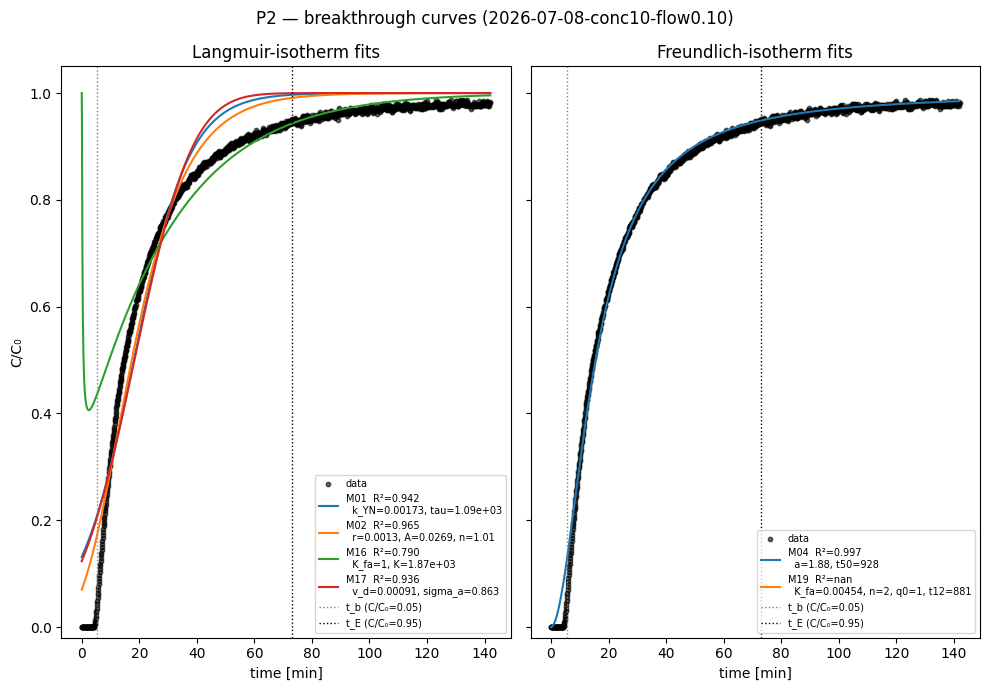

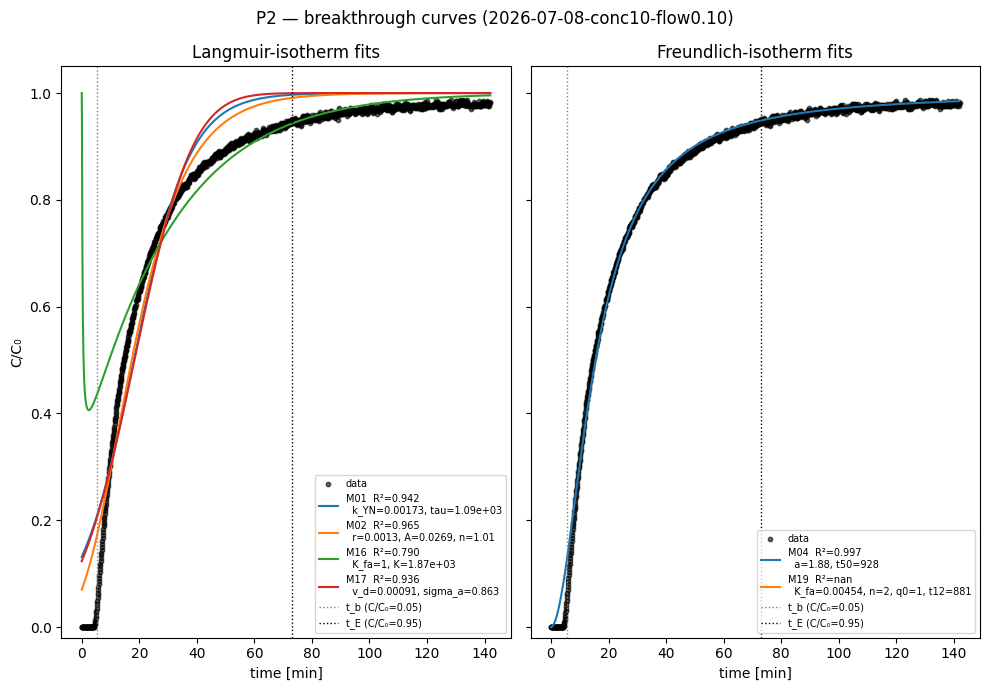

In [27]:
plot_P2(DEMO_ID, demo_run.df, RESULTS[DEMO_ID], out_dir=_demo_out)

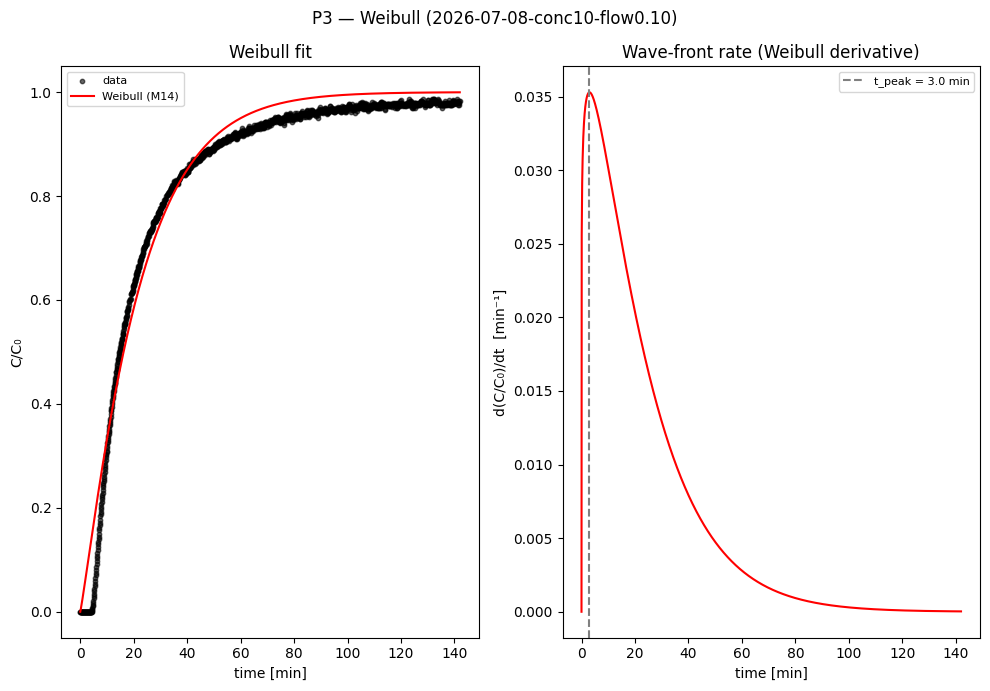

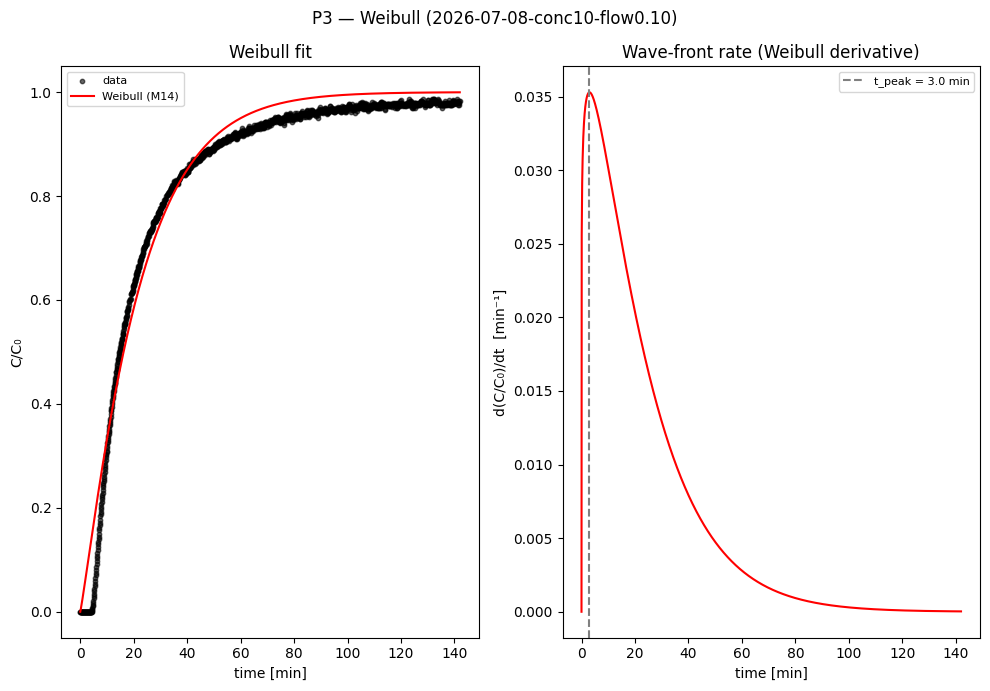

In [28]:
plot_P3(DEMO_ID, demo_run.df, RESULTS[DEMO_ID], out_dir=_demo_out)

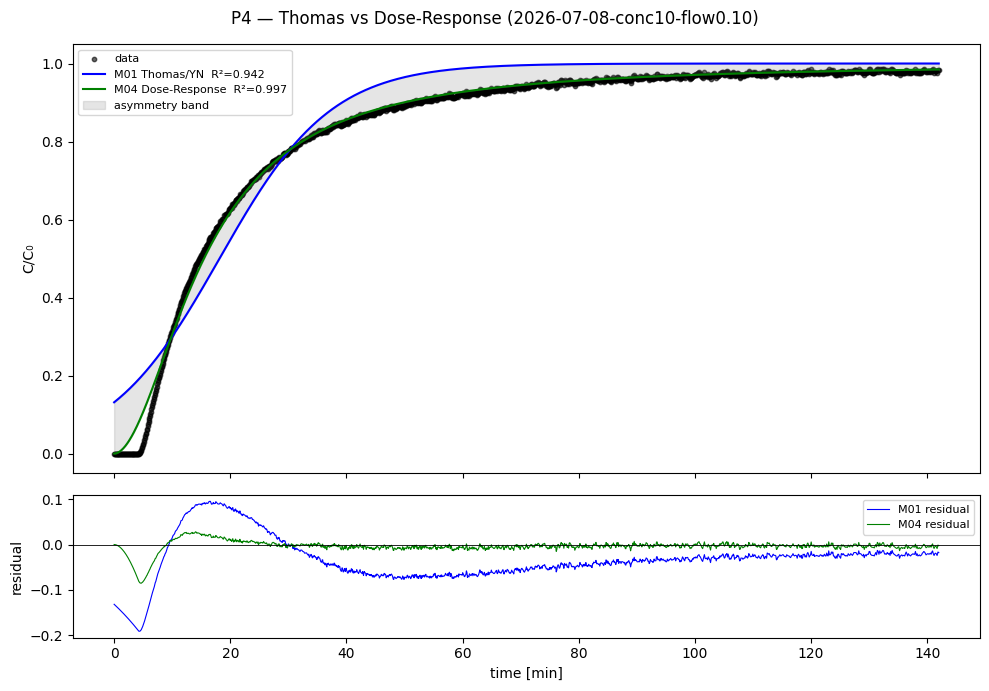

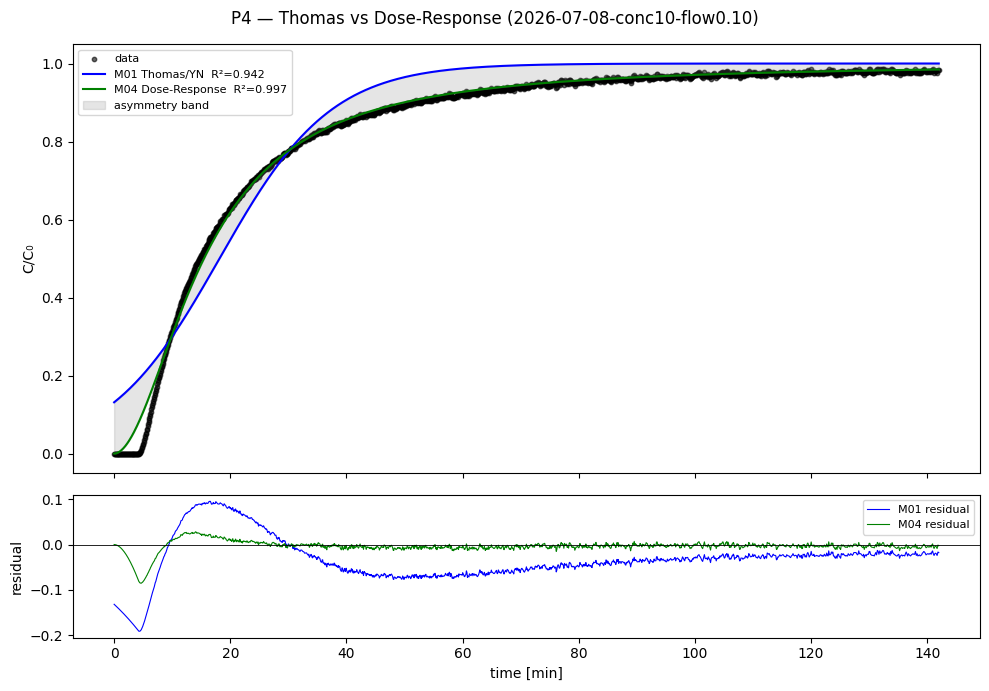

In [29]:
plot_P4(DEMO_ID, demo_run.df, RESULTS[DEMO_ID], out_dir=_demo_out)

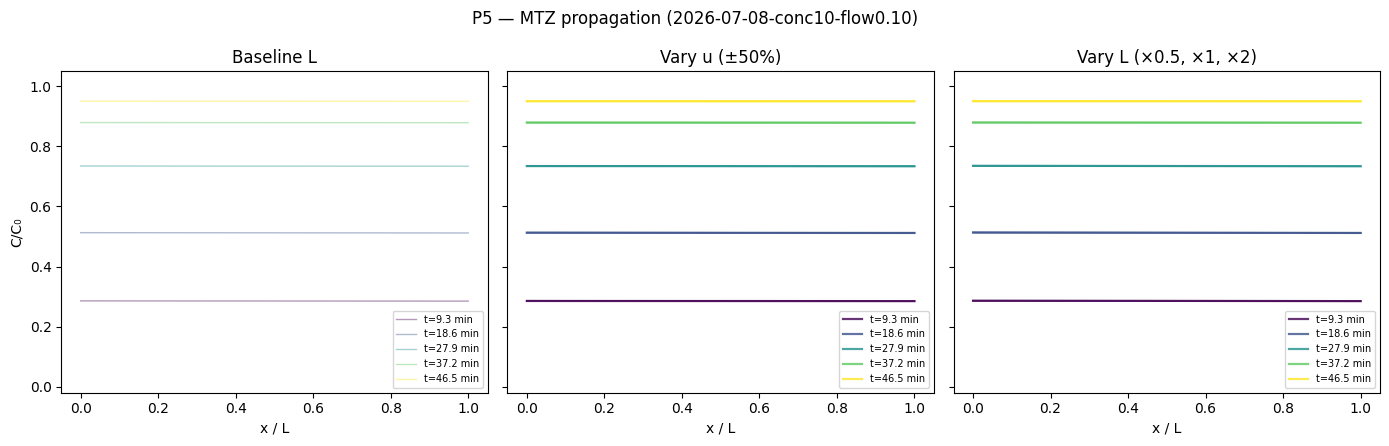

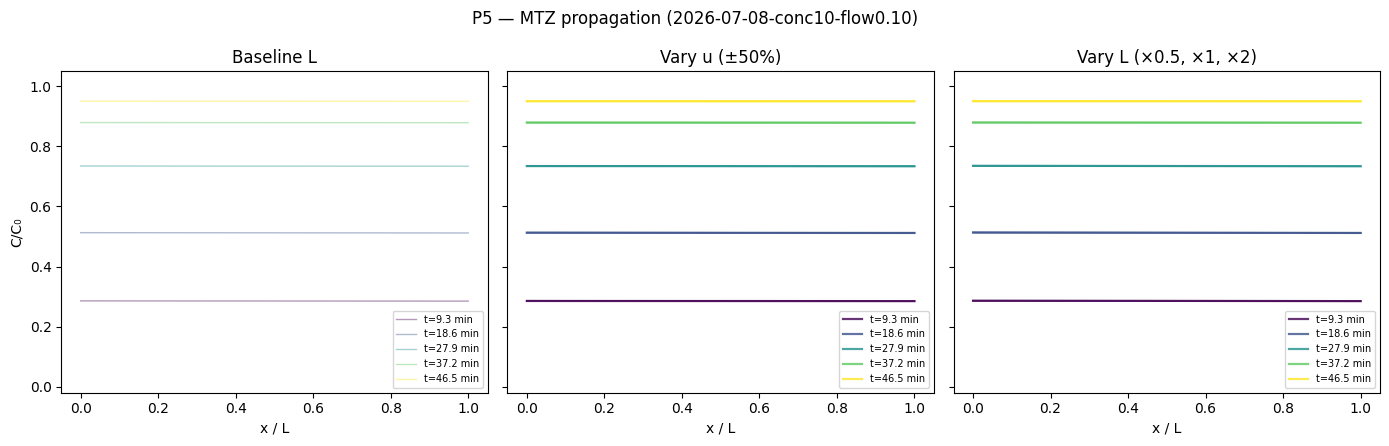

In [30]:
plot_P5(DEMO_ID, RESULTS[DEMO_ID], L_bed_m=_g["L_bed_m"],
        v_interstitial=_g["v_int"], out_dir=_demo_out)

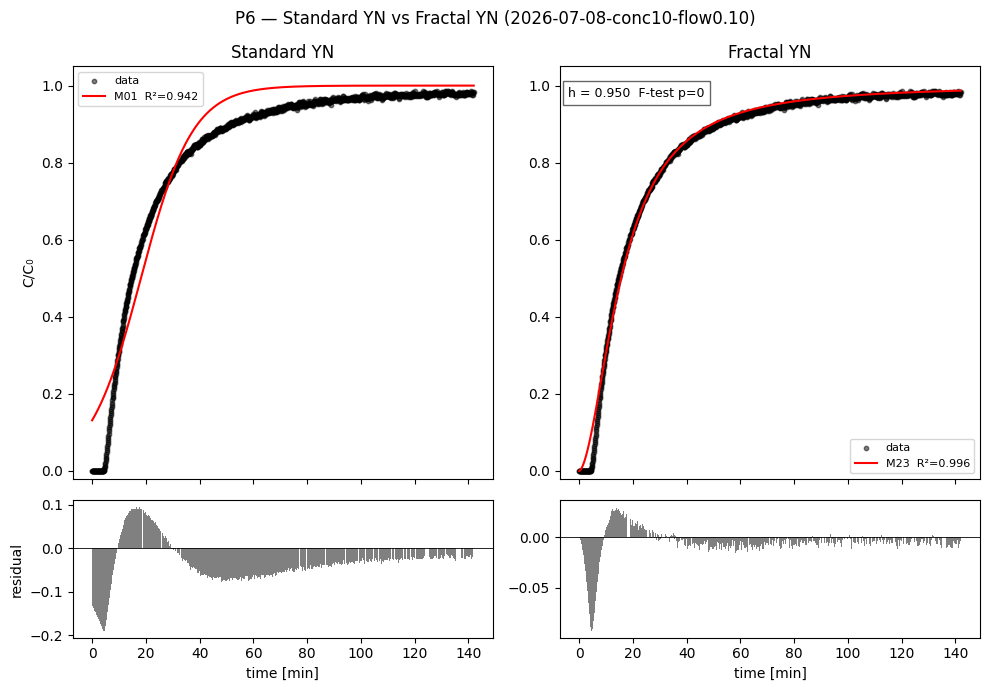

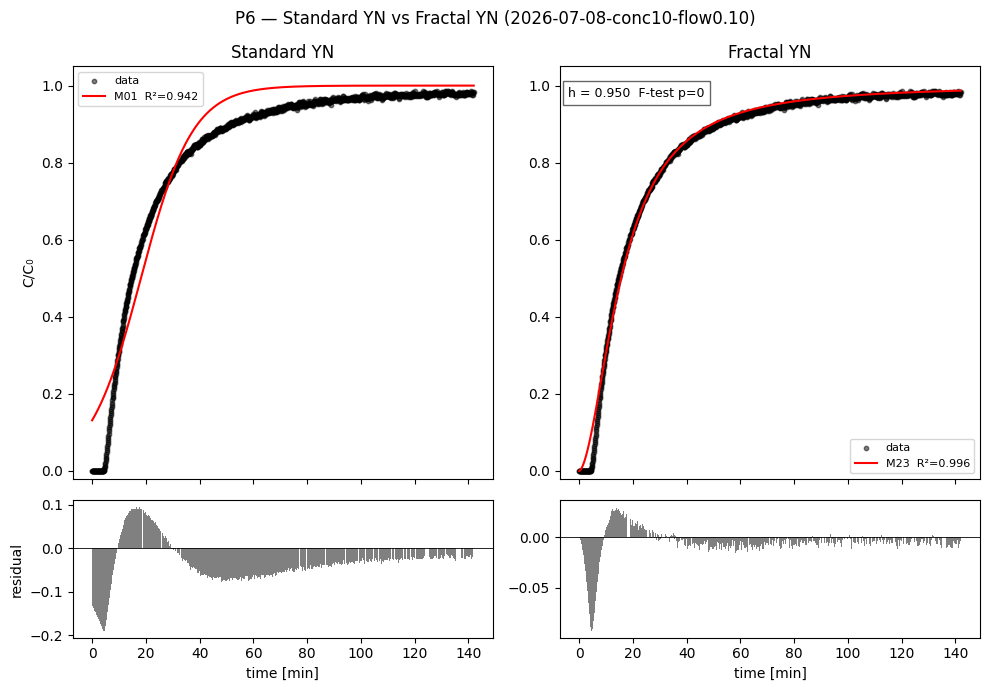

In [31]:
_sel = _ft[(_ft["simple"] == "M01") & (_ft["complex"] == "M23")]
_f_p = float(_sel["p_value"].iloc[0]) if not _sel.empty else None
plot_P6(DEMO_ID, demo_run.df, RESULTS[DEMO_ID], f_p_ba_vs_fractal=_f_p, out_dir=_demo_out)

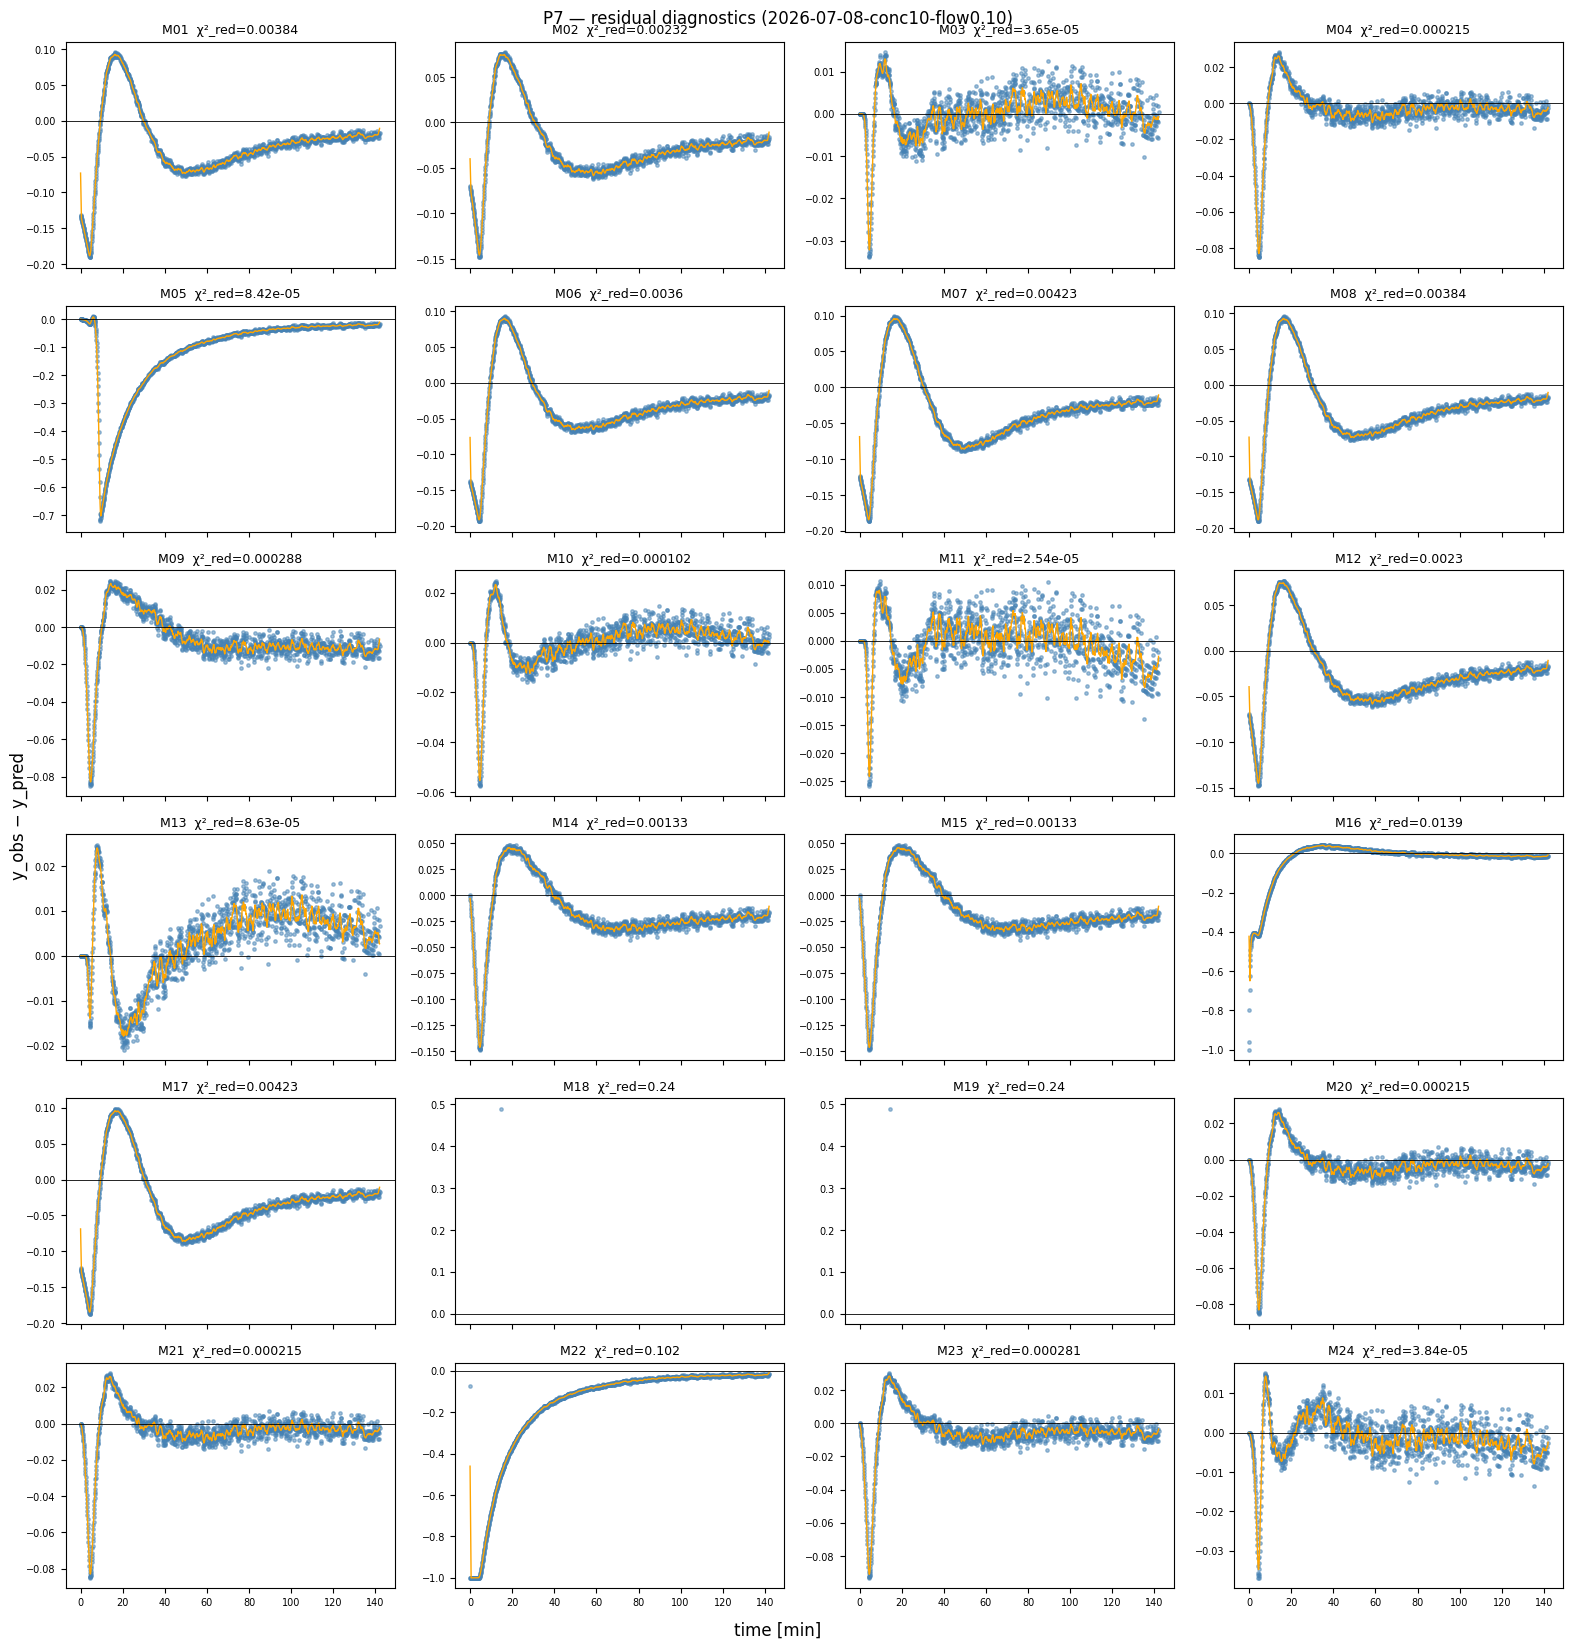

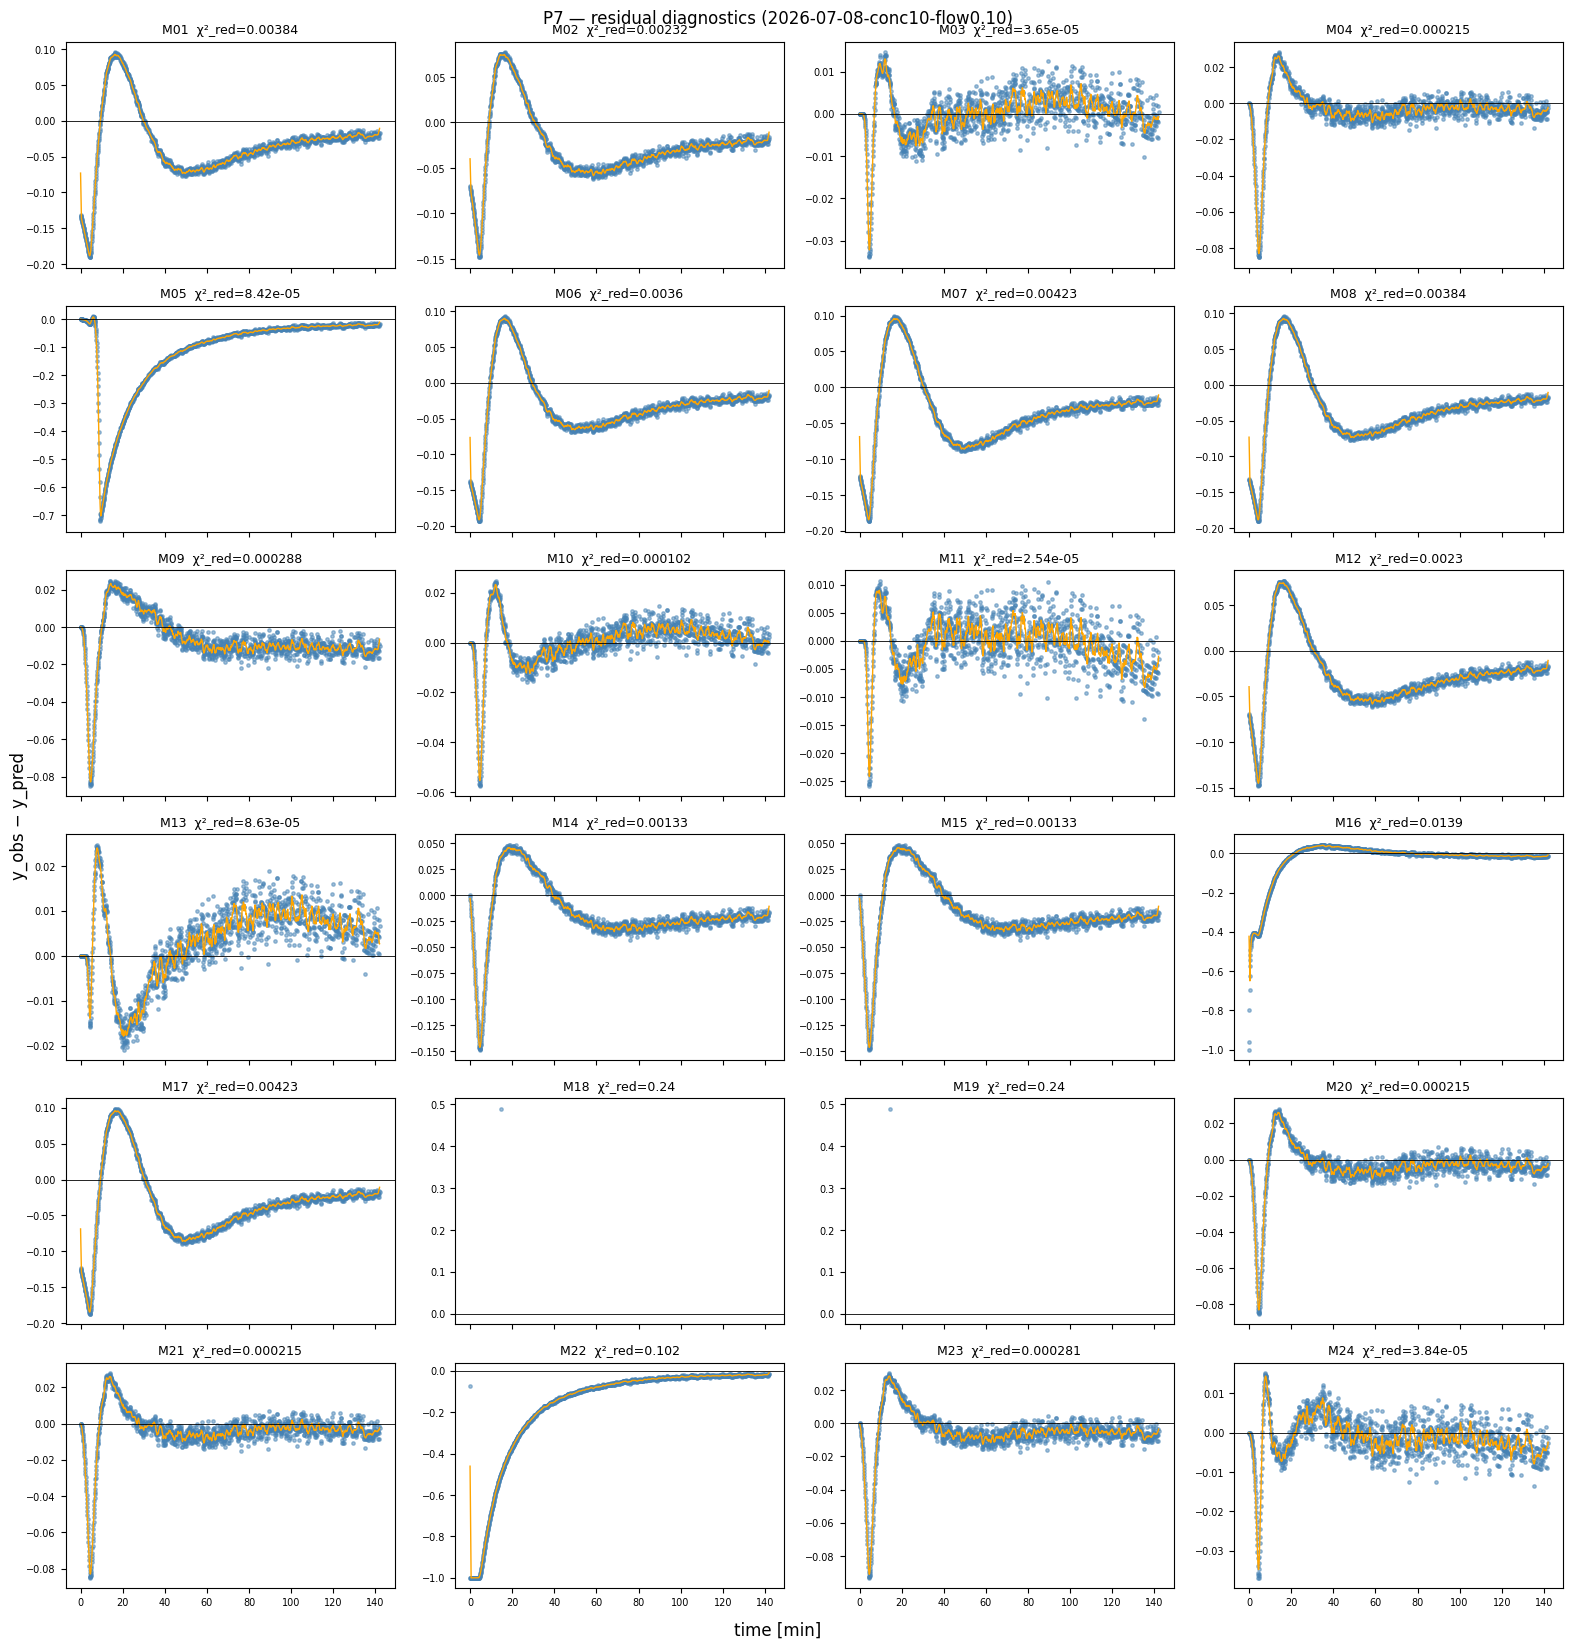

In [32]:
plot_P7(DEMO_ID, demo_run.df, RESULTS[DEMO_ID], out_dir=_demo_out)

In [33]:
print(sorted(p.name for p in _demo_out.glob("*.png")))

['P1_2026-07-08-conc10-flow0.10.png', 'P2_2026-07-08-conc10-flow0.10.png', 'P3_2026-07-08-conc10-flow0.10.png', 'P4_2026-07-08-conc10-flow0.10.png', 'P5_2026-07-08-conc10-flow0.10.png', 'P6_2026-07-08-conc10-flow0.10.png', 'P7_2026-07-08-conc10-flow0.10.png']


## 8 — All nine runs

### Definitions — the orchestration spine

Results CSV schema (trap 9): the `_s` spelling — `t_b_s`, `t_E_s`, `t50_s` — is
adopted, matching the on-disk CSVs and everything downstream. The old
`main.py` wrote bare `t_b`/`t_E`/`t50`; that fork is resolved in favour of `_s`.

In [34]:
RESULTS_COLUMNS = [
    "run_id", "fmt", "code", "name", "converged", "n", "p", "RSS", "R2", "AdjR2",
    "RMSE", "chi2_red", "AIC", "AICc", "W_AICc", "AAD", "params", "stderr", "message",
    "t_b_s", "t_E_s", "t50_s", "q_dyn_mol_per_kg", "L_MTZ_m", "efficiency",
]


def write_results_csv(path: Path, run: ParsedRun, results: dict[str, FitResult],
                      perf: PerformanceMetrics) -> pd.DataFrame:
    """Write one 24-row `results_<run_id>.csv` and return the frame."""
    rows = []
    for code, r in results.items():
        s = r.stats
        rows.append({
            "run_id": run.run_id, "fmt": run.fmt, "code": code, "name": r.name,
            "converged": r.converged, "n": s.n, "p": s.p, "RSS": s.rss,
            "R2": s.r2, "AdjR2": s.adj_r2, "RMSE": s.rmse, "chi2_red": s.chi2_red,
            "AIC": s.aic, "AICc": s.aicc, "W_AICc": s.aic_weight, "AAD": s.aad,
            "params": ";".join(f"{n}={v:.6g}" for n, v in zip(r.param_names, r.params)),
            "stderr": ";".join(f"{n}={se:.6g}" for n, se in zip(r.param_names, r.stderr)),
            "message": r.message,
            "t_b_s": perf.t_b, "t_E_s": perf.t_E, "t50_s": perf.t50,
            "q_dyn_mol_per_kg": perf.q_dyn_mol_per_kg,
            "L_MTZ_m": perf.L_MTZ_m, "efficiency": perf.efficiency,
        })
    out = pd.DataFrame(rows)[RESULTS_COLUMNS]
    path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(path, index=False)
    return out


def run_one(fpath: Path, verbose: bool = True) -> Optional[str]:
    """Parse, fit, measure, plot and persist one run. Returns its id, or None if skipped.

    Fits are memoised in the global `RESULTS`; with `REFIT = False` an already
    fitted run reuses its in-memory fits and only redraws.
    """
    run = parse_run(fpath)
    df = run.df
    if verbose:
        c0_str = f"{run.c0_ppm:.0f} ppm" if run.c0_ppm else "unknown"
        print(f"\n{'='*74}")
        print(f"Run: {run.run_id}  fmt={run.fmt}  n={len(df)}  C0={c0_str}")

    if run.mass_g is None or run.bed_height_cm is None or run.flow_ml_min is None:
        print(f"  [SKIP] {fpath.name}: no embedded mass/bed-height/flow — raw sensor log. "
              f"Geometry NOT fabricated; owner: lab.")
        return None
    if len(df) < 10:
        print(f"  [SKIP] {fpath.name}: only {len(df)} usable rows.")
        return None

    check_against_run_meta(run)                      # header vs RUN_META, loud on mismatch
    geom = run_geometry(run)
    PARSED[run.run_id], GEOM[run.run_id] = run, geom

    if verbose:
        print(f"     Q={geom['Q_lpm']:.3f} lpm | m={geom['m_g']:.4g} g | "
              f"L_bed={geom['L_bed_cm']:.2f} cm | d_c={geom['d_col_m']*1000:.1f} mm | "
              f"T={geom['T_K']:.1f} K | P={geom['P_Pa']:.0f} Pa")
        print(f"     A_c={geom['A_c']*1e4:.4f} cm2  rho_b={geom['rho_b']:.1f} kg/m3  "
              f"eps={geom['eps_b']:.4f}(floored)  u={geom['u']*100:.4f} cm/s  "
              f"v_int={geom['v_int']*100:.4f} cm/s")

    if REFIT or run.run_id not in RESULTS:
        RESULTS[run.run_id] = FITTER.fit_all(
            df, progress=lambda it: _tqdm(it, desc=run.run_id, leave=False))
    else:
        print(f"     [cached] reusing in-memory fits for {run.run_id}")
    results = RESULTS[run.run_id]

    t_arr = df["t"].to_numpy(dtype=float)
    y_arr = df["C_C0"].to_numpy(dtype=float)
    perf = performance_metrics(t_arr, y_arr, geom["flow_m3_s"], geom["c0_mol_m3"],
                               geom["mass_kg"], geom["L_bed_m"])
    PERF[run.run_id] = perf

    if verbose:
        table = ranking_table(results)
        print("\nModel rankings (sorted by AICc):")
        print(_tabulate(table.head(8).values.tolist(), headers=list(table.columns),
                        tablefmt="plain"))
        print(f"\nPerformance: t_b={perf.t_b/60:.2f} min  t_E={perf.t_E/60:.2f} min  "
              f"t50={perf.t50/60:.2f} min  q_dyn={perf.q_dyn_mol_per_kg:.4g} mol/kg  "
              f"L_MTZ={perf.L_MTZ_m*100:.2f} cm  psi={perf.efficiency:.3f}")
        print(f"   lab spreadsheet cross-check: t_b={run.lab_estimates.get('tb', float('nan')):.2f} min  "
              f"t_E={run.lab_estimates.get('te', float('nan')):.2f} min")

    ftests = nested_ftests(results, n=len(df))
    f_p = None
    if not ftests.empty:
        sel = ftests[(ftests["simple"] == "M01") & (ftests["complex"] == "M23")]
        if not sel.empty:
            f_p = float(sel["p_value"].iloc[0])

    out_dir = OUT_DIR / run.run_id
    write_results_csv(out_dir / f"results_{run.run_id}.csv", run, results, perf)

    plot_P1(run.run_id, results, out_dir=out_dir)
    plot_P2(run.run_id, df, results, out_dir=out_dir)
    plot_P3(run.run_id, df, results, out_dir=out_dir)
    plot_P4(run.run_id, df, results, out_dir=out_dir)
    plot_P5(run.run_id, results, L_bed_m=geom["L_bed_m"],
            v_interstitial=geom["v_int"], out_dir=out_dir)
    plot_P6(run.run_id, df, results, f_p_ba_vs_fractal=f_p, out_dir=out_dir)
    plot_P7(run.run_id, df, results, out_dir=out_dir)
    plt.close("all")          # trap 2: 9 runs x 7 plots would otherwise leak 63 figures

    if verbose:
        print(f"  -> {out_dir}")
    return run.run_id

In [35]:
_t0 = time.time()
_done = []
for fpath in sorted(DATA_DIR.glob("*.csv")):
    rid = run_one(fpath)
    if rid is not None:
        _done.append(rid)
print(f"\n{'='*74}\nCompleted {len(_done)} runs in {time.time() - _t0:.1f} s")
assert set(_done) == set(RUN_IDS), f"expected the nine RUN_META ids, got {sorted(_done)}"
print("all nine expected run ids processed")


Run: 2026-06-26-conc5-flow0.05  fmt=D  n=1658  C0=50000 ppm
     Q=0.050 lpm | m=8 g | L_bed=23.50 cm | d_c=8.2 mm | T=298.6 K | P=100800 Pa
     A_c=0.5281 cm2  rho_b=644.6 kg/m3  eps=0.3000(floored)  u=1.5780 cm/s  v_int=5.2599 cm/s


2026-06-26-conc5-flow0.05:   0%|          | 0/24 [00:00<?, ?it/s]

C:\Users\User\AppData\Local\Temp\ipykernel_15944\2021204862.py:54: RuntimeWarning: overflow encountered in sinh
  return 0.5 * (1.0 + (2.0 / np.pi) * np.arctan(np.sinh(k0 * np.power(t, -h) * (t - tau0))))



Model rankings (sorted by AICc):
code    name                                           p     AdjR2        RMSE      AICc        W_AICc      chi2_nu  ok
M11     Fractal Error-Function (Hu 2024)               3  0.999027  0.00905844  -15594.6  0.5           8.21049e-05  True
M24     Parallel two-component sigmoidal (Blagojev)    5  0.9984    0.0116097   -14767.8  2.80822e-180  0.00013503   True
M13     Log-Gompertz (Chu 2020)                        2  0.998275  0.0120646   -14646.3  1.20365e-206  0.000145555  True
M10     Fractal Gudermannian (Hu 2024)                 3  0.997339  0.0149796   -13926.7  9.85968e-305  0.000224523  True
M03     Fractal Clark                                  4  0.997067  0.0157207   -13764.6  9.85968e-305  0.00024744   True
M04     Modified Dose-Response (Yan)                   2  0.988835  0.0306932   -11550    9.85968e-305  0.000942075  True
M21     Log-modified Yoon-Nelson                       2  0.988835  0.0306932   -11550    9.85968e-305  0.00094207

  -> C:\Users\User\Projects\GitHub\ProjID3\src\solver\breakthrough_out\2026-06-26-conc5-flow0.05

Run: 2026-07-03-conc5-flow0.10  fmt=D  n=413  C0=50010 ppm
     Q=0.100 lpm | m=8 g | L_bed=24.00 cm | d_c=8.2 mm | T=299.0 K | P=101200 Pa
     A_c=0.5281 cm2  rho_b=631.2 kg/m3  eps=0.3000(floored)  u=3.1560 cm/s  v_int=10.5199 cm/s


...


Model rankings (sorted by AICc):
code    name                                           p     AdjR2        RMSE       AICc        W_AICc      chi2_nu  ok
M11     Fractal Error-Function (Hu 2024)               3  0.999366  0.00650415  -11547     0.5           4.2341e-05   True
M24     Parallel two-component sigmoidal (Blagojev)    5  0.999238  0.00712259  -11334.6   7.56314e-47   5.08645e-05  True
M03     Fractal Clark                                  4  0.999005  0.00814577  -11028.7   2.8399e-113   6.64696e-05  True
M13     Log-Gompertz (Chu 2020)                        2  0.998813  0.00890402  -10828.5   9.79821e-157  7.92815e-05  True
M10     Fractal Gudermannian (Hu 2024)                 3  0.997912  0.0118015   -10180.3   1.64552e-297  0.000139398  True
M04     Modified Dose-Response (Yan)                   2  0.995029  0.0182182    -9186.22  9.85968e-305  0.000331904  True
M20     Log-modified Bohart-Adams                      2  0.995029  0.0182182    -9186.22  9.85968e-305  0.

  -> C:\Users\User\Projects\GitHub\ProjID3\src\solver\breakthrough_out\2026-07-10-conc15-flow0.10

Run: 2026-07-15-conc15-flow0.15  fmt=D  n=1002  C0=150100 ppm
     Q=0.150 lpm | m=8 g | L_bed=24.00 cm | d_c=8.2 mm | T=300.6 K | P=101600 Pa
     A_c=0.5281 cm2  rho_b=631.2 kg/m3  eps=0.3000(floored)  u=4.7339 cm/s  v_int=15.7798 cm/s


2026-07-15-conc15-flow0.15:   0%|          | 0/24 [00:00<?, ?it/s]


Model rankings (sorted by AICc):
code    name                                           p     AdjR2        RMSE       AICc        W_AICc      chi2_nu  ok
M11     Fractal Error-Function (Hu 2024)               3  0.999259  0.00606872  -10225.6   0.5           3.68662e-05  True
M24     Parallel two-component sigmoidal (Blagojev)    5  0.999024  0.0069594    -9947.14  3.38703e-61   4.8579e-05   True
M13     Log-Gompertz (Chu 2020)                        2  0.99895   0.00722864   -9877.12  2.11713e-76   5.22532e-05  True
M03     Fractal Clark                                  4  0.998746  0.0078926    -9696.99  1.62565e-115  6.2418e-05   True
M10     Fractal Gudermannian (Hu 2024)                 3  0.997815  0.0104228    -9141.76  4.40609e-236  0.000108743  True
M04     Modified Dose-Response (Yan)                   2  0.993669  0.01775      -8076.86  9.85968e-305  0.000315062  True
M21     Log-modified Yoon-Nelson                       2  0.993669  0.01775      -8076.86  9.85968e-305  0.

  -> C:\Users\User\Projects\GitHub\ProjID3\src\solver\breakthrough_out\2026-07-15-conc15-flow0.15

Run: 2026-07-17-conc15-flow0.1  fmt=A  n=1926  C0=185000 ppm
  [SKIP] 2026-07-17-conc15-flow0.1.csv: no embedded mass/bed-height/flow — raw sensor log. Geometry NOT fabricated; owner: lab.

Run: 2026-07-17-conc15-flow0.15  fmt=A  n=905  C0=200010 ppm
  [SKIP] 2026-07-17-conc15-flow0.15.csv: no embedded mass/bed-height/flow — raw sensor log. Geometry NOT fabricated; owner: lab.

Completed 9 runs in 240.1 s
all nine expected run ids processed


In [36]:
for rid in RUN_IDS:
    d = OUT_DIR / rid
    csv = d / f"results_{rid}.csv"
    n_rows = len(pd.read_csv(csv))
    pngs = sorted(p.name for p in d.glob("P?_*.png"))
    assert n_rows == 24, f"{rid}: {n_rows} rows, expected 24"
    assert len(pngs) == 7, f"{rid}: {len(pngs)} plots, expected 7"
    print(f"{rid:<30} {n_rows:>3} rows  {len(pngs)} plots  {csv.stat().st_size/1024:5.1f} kB")
print("\nschema:", list(pd.read_csv(OUT_DIR / RUN_IDS[0] / f'results_{RUN_IDS[0]}.csv').columns))

2026-06-26-conc5-flow0.05       24 rows  7 plots    9.7 kB
2026-07-03-conc5-flow0.10       24 rows  7 plots    9.9 kB
2026-07-08-conc5-flow0.15       24 rows  7 plots   10.0 kB
2026-07-08-conc10-flow0.05      24 rows  7 plots    9.4 kB
2026-07-08-conc10-flow0.10      24 rows  7 plots   10.2 kB


2026-07-08-conc10-flow0.15      24 rows  7 plots    9.8 kB
2026-07-10-conc15-flow0.05      24 rows  7 plots   10.2 kB
2026-07-10-conc15-flow0.10      24 rows  7 plots    9.7 kB
2026-07-15-conc15-flow0.15      24 rows  7 plots    9.6 kB

schema: ['run_id', 'fmt', 'code', 'name', 'converged', 'n', 'p', 'RSS', 'R2', 'AdjR2', 'RMSE', 'chi2_red', 'AIC', 'AICc', 'W_AICc', 'AAD', 'params', 'stderr', 'message', 't_b_s', 't_E_s', 't50_s', 'q_dyn_mol_per_kg', 'L_MTZ_m', 'efficiency']


## 9 — Cross-run summary

The 3×3 design: {5, 10, 15} % CO₂ × {0.05, 0.10, 0.15} lpm.

In [37]:
summary = pd.DataFrame([{
    "run_id": rid,
    "C0_ppm": GEOM[rid]["c0_ppm"],
    "conc_pct": round(GEOM[rid]["c0_ppm"] / 1e4),
    "Q_lpm": GEOM[rid]["Q_lpm"],
    "L_bed_cm": GEOM[rid]["L_bed_cm"],
    "u_cm_s": GEOM[rid]["u"] * 100,
    "t_b_min": PERF[rid].t_b / 60,
    "t_E_min": PERF[rid].t_E / 60,
    "t50_min": PERF[rid].t50 / 60,
    "q_dyn_mol_kg": PERF[rid].q_dyn_mol_per_kg,
    "L_MTZ_cm": PERF[rid].L_MTZ_m * 100,
    "psi": PERF[rid].efficiency,
    "best_AICc": ranking_table(RESULTS[rid]).iloc[0]["code"],
    "best_AdjR2": ranking_table(RESULTS[rid]).iloc[0]["AdjR2"],
    "lab_t_b_min": PARSED[rid].lab_estimates.get("tb", np.nan),
    "lab_t_E_min": PARSED[rid].lab_estimates.get("te", np.nan),
} for rid in RUN_IDS])
summary.round(4)

,run_id,C0_ppm,conc_pct,Q_lpm,L_bed_cm,u_cm_s,t_b_min,t_E_min,t50_min,q_dyn_mol_kg,L_MTZ_cm,psi,best_AICc,best_AdjR2,lab_t_b_min,lab_t_E_min
0,2026-06-26-conc5-flow0.05,50000.0,5,0.05,23.5,1.5780,23.9575,252.0000,49.0850,0.9459,12.8671,0.3158,M11,0.9990,23.83,271.67
1,2026-07-03-conc5-flow0.10,50010.0,5,0.10,24.0,3.1560,10.6502,111.5627,26.1175,0.9548,13.1456,0.2760,M24,0.9992,10.39,111.20
2,2026-07-08-conc5-flow0.15,50220.0,5,0.15,23.5,4.7339,4.1997,112.0230,12.8461,0.9681,12.1905,0.1565,M11,0.9996,4.08,119.69
3,2026-07-08-conc10-flow0.05,99000.0,10,0.05,23.0,1.5780,19.0600,163.5850,37.6400,1.3357,12.8399,0.3525,M11,0.9996,19.00,181.04
4,2026-07-08-conc10-flow0.10,100580.0,10,0.10,23.3,3.1560,5.4329,72.9325,14.6789,1.1333,12.5178,0.2261,M11,0.9996,5.42,72.85
5,2026-07-08-conc10-flow0.15,100000.0,10,0.15,24.0,4.7339,3.5516,71.6050,10.8829,1.3800,12.5952,0.1740,M03,0.9992,3.40,73.82
6,2026-07-10-conc15-flow0.05,150970.0,15,0.05,24.5,1.5780,17.6802,127.7214,30.9187,1.6272,13.9457,0.4060,M11,0.9993,17.67,147.59
7,2026-07-10-conc15-flow0.10,149800.0,15,0.10,24.0,3.1560,4.2936,54.7168,10.5667,1.2119,12.9416,0.2465,M11,0.9994,4.25,56.97
8,2026-07-15-conc15-flow0.15,150100.0,15,0.15,24.0,4.7339,2.5853,39.1448,6.4457,1.2091,12.7925,0.2150,M11,0.9993,2.58,40.63


In [38]:
print("t_b vs the lab's own spreadsheet estimate (unit sanity check):")
_chk = summary[["run_id", "t_b_min", "lab_t_b_min", "t_E_min", "lab_t_E_min"]].copy()
_chk["t_b_ratio"] = _chk["t_b_min"] / _chk["lab_t_b_min"]
_chk["t_E_ratio"] = _chk["t_E_min"] / _chk["lab_t_E_min"]
print(_chk.round(3).to_string(index=False))
print(f"\nmedian t_b ratio = {_chk['t_b_ratio'].median():.3f}, "
      f"median t_E ratio = {_chk['t_E_ratio'].median():.3f}  "
      f"(≈1 confirms minutes→seconds handled correctly)")

t_b vs the lab's own spreadsheet estimate (unit sanity check):
                    run_id  t_b_min  lab_t_b_min  t_E_min  lab_t_E_min  t_b_ratio  t_E_ratio
 2026-06-26-conc5-flow0.05   23.958        23.83  252.000       271.67      1.005      0.928
 2026-07-03-conc5-flow0.10   10.650        10.39  111.563       111.20      1.025      1.003
 2026-07-08-conc5-flow0.15    4.200         4.08  112.023       119.69      1.029      0.936
2026-07-08-conc10-flow0.05   19.060        19.00  163.585       181.04      1.003      0.904
2026-07-08-conc10-flow0.10    5.433         5.42   72.933        72.85      1.002      1.001
2026-07-08-conc10-flow0.15    3.552         3.40   71.605        73.82      1.045      0.970
2026-07-10-conc15-flow0.05   17.680        17.67  127.721       147.59      1.001      0.865
2026-07-10-conc15-flow0.10    4.294         4.25   54.717        56.97      1.010      0.960
2026-07-15-conc15-flow0.15    2.585         2.58   39.145        40.63      1.002      0.963

median

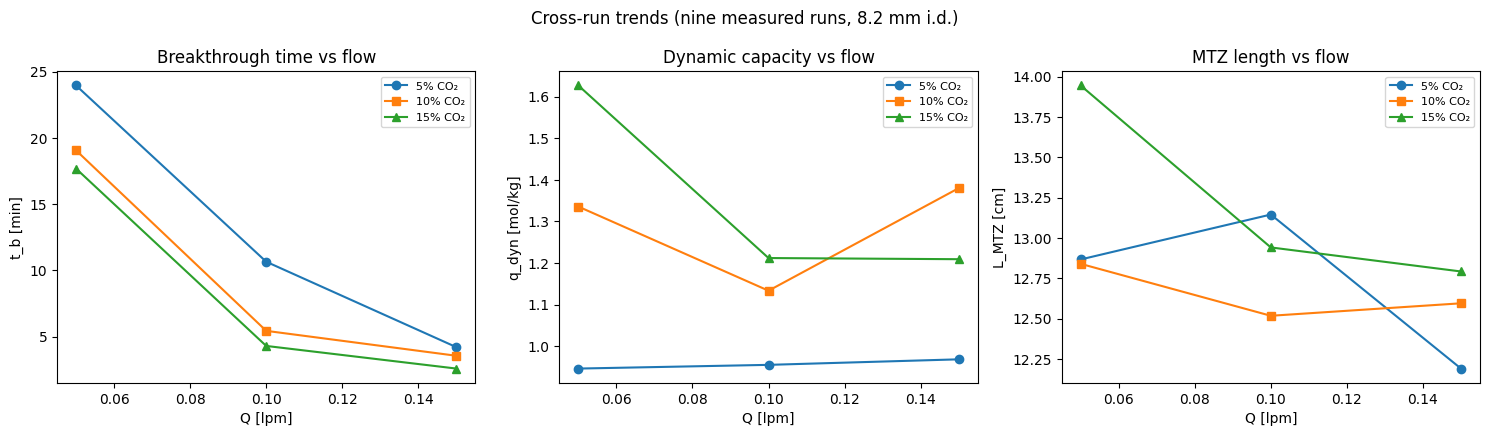

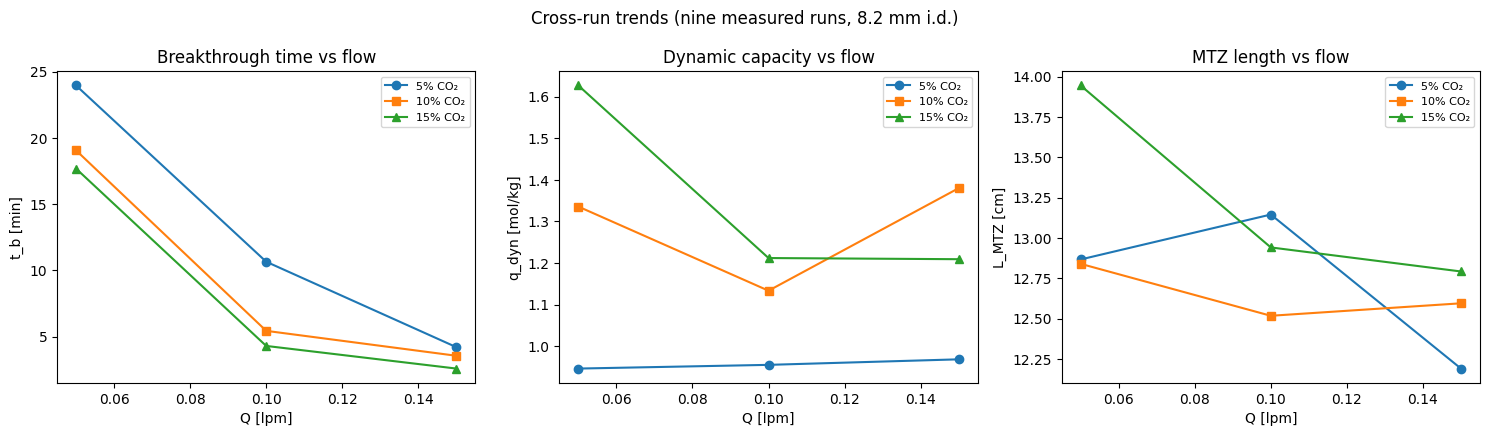

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4))
markers = {5: "o", 10: "s", 15: "^"}
for pct, grp in summary.groupby("conc_pct"):
    grp = grp.sort_values("Q_lpm")
    axes[0].plot(grp["Q_lpm"], grp["t_b_min"], marker=markers.get(pct, "o"),
                 label=f"{pct}% CO₂")
    axes[1].plot(grp["Q_lpm"], grp["q_dyn_mol_kg"], marker=markers.get(pct, "o"),
                 label=f"{pct}% CO₂")
    axes[2].plot(grp["Q_lpm"], grp["L_MTZ_cm"], marker=markers.get(pct, "o"),
                 label=f"{pct}% CO₂")
for ax, ylab, title in zip(
        axes,
        ["t_b [min]", "q_dyn [mol/kg]", "L_MTZ [cm]"],
        ["Breakthrough time vs flow", "Dynamic capacity vs flow", "MTZ length vs flow"]):
    ax.set_xlabel("Q [lpm]"); ax.set_ylabel(ylab); ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("Cross-run trends (nine measured runs, 8.2 mm i.d.)")
fig.tight_layout()
fig.savefig(OUT_DIR / "cross_run_trends.png", dpi=_DPI)
fig

In [40]:
# Which models win, across the nine runs.
_all_ranks = []
for rid in RUN_IDS:
    tbl = ranking_table(RESULTS[rid]).reset_index().rename(columns={"index": "rank"})
    tbl["rank"] += 1
    tbl["run_id"] = rid
    _all_ranks.append(tbl)
ranks = pd.concat(_all_ranks, ignore_index=True)

by_model = (ranks.groupby("code")
            .agg(mean_rank=("rank", "mean"), mean_AdjR2=("AdjR2", "mean"),
                 wins=("rank", lambda s: int((s == 1).sum())),
                 top3=("rank", lambda s: int((s <= 3).sum())),
                 n_converged=("ok", "sum"))
            .sort_values("mean_rank"))
print("Model performance across all nine runs (rank 1 = best AICc in that run):")
print(by_model.round(4).to_string())

Model performance across all nine runs (rank 1 = best AICc in that run):
      mean_rank  mean_AdjR2  wins  top3  n_converged
code                                                
M11      1.3333      0.9993     7     9            9
M24      2.6667      0.9989     1     7            9
M13      3.1111      0.9984     0     5            9
M03      3.5556      0.9981     1     4            9
M10      4.3333      0.9979     0     2            9
M04      6.3333      0.9926     0     0            9
M20      7.2222      0.9926     0     0            9
M21      7.7778      0.9926     0     0            9
M23      9.1111      0.9911     0     0            9
M09      9.5556      0.9907     0     0            9
M14     11.4444      0.9711     0     0            9
M15     12.4444      0.9711     0     0            9
M12     12.5556      0.9564     0     0            9
M02     13.5556      0.9561     0     0            9
M06     15.0000      0.9349     0     0            9
M01     16.3333      0.931

In [41]:
print("Winner per run:")
print(summary[["run_id", "conc_pct", "Q_lpm", "best_AICc", "best_AdjR2"]]
      .to_string(index=False))

Winner per run:
                    run_id  conc_pct  Q_lpm best_AICc  best_AdjR2
 2026-06-26-conc5-flow0.05         5   0.05       M11    0.999027
 2026-07-03-conc5-flow0.10         5   0.10       M24    0.999150
 2026-07-08-conc5-flow0.15         5   0.15       M11    0.999624
2026-07-08-conc10-flow0.05        10   0.05       M11    0.999567
2026-07-08-conc10-flow0.10        10   0.10       M11    0.999616
2026-07-08-conc10-flow0.15        10   0.15       M03    0.999236
2026-07-10-conc15-flow0.05        15   0.05       M11    0.999342
2026-07-10-conc15-flow0.10        15   0.10       M11    0.999366
2026-07-15-conc15-flow0.15        15   0.15       M11    0.999259


In [42]:
# Isotherm view: q_dyn against inlet concentration, linearised both ways.
_c_mol_m3 = np.array([GEOM[rid]["c0_mol_m3"] for rid in RUN_IDS])
_q = np.array([PERF[rid].q_dyn_mol_per_kg for rid in RUN_IDS])
print("Langmuir (linearised): ", {k: round(v, 6) for k, v in langmuir_linear_fit(_c_mol_m3, _q).items()})
print("Freundlich (log-log):  ", {k: round(v, 6) for k, v in freundlich_log_fit(_c_mol_m3, _q).items()})
print("\n⚑ Nine points spanning three concentrations at three flows — q_dyn is a")
print("  DYNAMIC capacity, not an equilibrium loading, so these linearisations are")
print("  descriptive only. Do not report them as isotherm parameters.")

Langmuir (linearised):  {'q_m': 1.715003, 'K_L': 0.624239, 'r2': 0.758508}
Freundlich (log-log):   {'K_F': 0.774556, 'inv_n': 0.319378, 'r2': 0.669669}

⚑ Nine points spanning three concentrations at three flows — q_dyn is a
  DYNAMIC capacity, not an equilibrium loading, so these linearisations are
  descriptive only. Do not report them as isotherm parameters.


## 10 — What was dropped, and why

| module | dropped because |
|---|---|
| `main.py` | argparse CLI superseded by the pipeline spine; its geometry defaults (`--column-diameter 3.37`, `--column-length 32.5`) belong to a different rig. |
| `cross_run_figs.py` | keyed to the legacy synthetic `NNNml_Ng` run directories, and reads `breakthrough_out/` as an *input*. |
| `assemble_may_prompt.py` | built on the superseded five-run / 8.5 mm basis, reads `breakthrough_out/` as an input, and `mkdir`s at import time. Its tables/figures, if wanted, must be re-derived from `RESULTS` on the nine-run basis. |
| `mtz_fem.FEMesh` / `build_mesh` / `assemble_upwind` | dead scaffold — nothing calls them. Only `travelling_wave` and `project_snapshots` (used by P5) were ported. |
| `__init__.py` | eager submodule imports; meaningless in a notebook. |

`breakthrough_out/` is a **cache, not an input** — nothing above reads a
previously written `results_*.csv`.

### The ten port-time traps

| # | trap | disposition |
|---|---|---|
| 1 | `matplotlib.use("Agg")` at import | **dropped** — would kill `%matplotlib inline` |
| 2 | figures never closed | **handled** — `plt.close("all")` at the end of each run in `run_one` |
| 3 | `_save` only wrote to disk | **handled** — saves at 300 dpi *and* returns the figure for inline display |
| 4 | `rank_aicc` in-place mutation + pairwise-logit `W_AICc` | **ported verbatim**, with the non-standard formula documented in its docstring |
| 5 | `M05` Wolborska `early_only` | **handled** — fit *and* statistics restricted to `0.005 < C/C0 ≤ 0.15`, ≥3 points required |
| 6 | `M20` registry name `log_a0_C0` vs keyword `log_a0_over_C0` | **handled** — the fitter calls positionally; noted in the model docstring |
| 7 | `M18`/`M19` implicit, NaN where `brentq` fails | **handled** — L-BFGS-B on RSS, NaNs dropped by `compute_stats`; not "patched" |
| 8 | output path bug (`DATA_DIR` repo-relative, `OUT_DIR` bare) | **handled** — both anchored to an absolute `REPO`; output to `src/solver/breakthrough_out/` |
| 9 | results-CSV schema fork `t_b` vs `t_b_s` | **handled** — `_s` spelling adopted, matching the on-disk CSVs and everything downstream |
| 10 | `q_dyn_trapz` `np.trapezoid` + removed `/1000` | **handled** — corrected version kept; pre-2026-05-31 CSVs are 1000× low |

### Deviations from the task brief (stated, not hidden)

1. **`parse_format_d` already exists in the repo.** The brief states that
   `breakthrough_fit/parse.py` dispatches format `"D"` to a missing
   `parse_format_d` and that every one of the nine runs therefore raises
   `AttributeError`. As of this repo state it is implemented (`parse.py`
   lines 318–401) and the nine runs parse. The Format-D reader here is
   therefore a *port with additions*, not net-new code: the prose-block
   regexes were extended to flow rate and C₀, and the lab's `tb/qb/te/qe`
   block (cols 12–13) is now captured as an independent cross-check.
2. **`RUN_META` no longer exists in `new_runs_pipeline.py`.** That module now
   reads mass/bed height/flow/C₀/diameter per file from the Format-D header.
   The `RUN_META` table above is retained purely as the assertion target the
   brief asks for — `check_against_run_meta` raises on any disagreement, so
   neither source is silently preferred. All nine agree.
3. **Excluded files.** The two `2026-07-17-*` sensor logs are skipped by
   `run_one`'s missing-metadata guard, and the skip is printed.

## 11 — Self-containment

The acceptance test: rename `src/solver/breakthrough_fit/` and re-run. The
check below asserts the package is not loaded and that no forbidden construct
appears in this notebook's **code** cells. (The grep is over code cells only —
the markdown cells name the forbidden constructs in prose, which is the point
of documenting them. The tokens below are assembled by concatenation so that
this cell's own source cannot match itself.)

In [43]:
import json

_forbidden = ["import " + "breakthrough_fit", "from " + "breakthrough_fit",
              "from " + ".models", "sys.path." + "append", "sys.path." + "insert",
              "%" + "run ", "%" + "load ", "import" + "lib"]

_nb = REPO / "src" / "solver" / "breakthrough_analysis.ipynb"
if _nb.exists():
    _cells = json.loads(_nb.read_text(encoding="utf-8"))["cells"]
    _code_src = "\n".join("".join(c["source"]) for c in _cells if c["cell_type"] == "code")
    _hits = sorted({tok for tok in _forbidden if tok in _code_src})
    print(f"grepped {sum(c['cell_type'] == 'code' for c in _cells)} code cells "
          f"({len(_code_src)} chars)")
    print("forbidden constructs found:", _hits or "none")
    assert not _hits, f"self-containment violated: {_hits}"
else:
    print(f"[note] {_nb.name} not found at {_nb.parent} — skipping source grep")

_loaded = [m for m in sys.modules if m.startswith("breakthrough_fit")]
print("breakthrough_fit modules imported:", _loaded or "none")
assert not _loaded, f"breakthrough_fit was imported: {_loaded}"

_adjacent = [p.name for p in (REPO / "src" / "solver").glob("*.py")]
print("\n.py files next to the notebook (none of which it imports):")
print(" ", ", ".join(sorted(_adjacent)))
print("\nSelf-containment checks pass.")

grepped 43 code cells (84811 chars)
forbidden constructs found: none
breakthrough_fit modules imported: none

.py files next to the notebook (none of which it imports):
  heat_eq_mol.py, illustration.py, mechanistic_selfcontained.py, mechanistic_verify.py, new_runs_pipeline.py, pde_mol.py, psi_quadrature_proof_checks.py, psi_quadrature_verify.py

Self-containment checks pass.


### Rename test — executed result

The acceptance test was run for real, not asserted from inspection:

```
mv src/solver/breakthrough_fit src/solver/breakthrough_fit_RENAMED
cd src/solver && jupyter nbconvert --to notebook --execute --inplace breakthrough_analysis.ipynb
```

* Completed top-to-bottom with zero errors, from a **different working
  directory** (`src/solver`, not the repo root) — `find_repo_root` handles both.
* All nine `results_<run_id>.csv` files were compared against the pre-rename
  run, joined on `(run_id, code)`, over `AICc`, `AdjR2`, `RMSE`,
  `q_dyn_mol_per_kg`, `t_b_s`, `t_E_s`, `t50_s`, `W_AICc`, `RSS`, `R2`, `AIC`:
  **worst absolute difference 0.000e+00**, and the `params` blobs are
  byte-identical. The package was then renamed back.